In [1]:
import os
CUDA_LAUNCH_BLOCKING=1
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64,garbage_collection_threshold:0.6"

import sys
import numpy as np
import pandas as pd
from pathlib import Path
import logging
import json
import muon as mu
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg_celltype as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
from torch.utils.data import ConcatDataset, DataLoader
from scripts.train_tf_to_tg_celltype_model import (
    binding_score_cache_path,
    TFTGEdgeBagDataset,
)

DATA_DIR = PROJECT_DIR.parent / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

2026-10-02 10:05:13.993106: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-02 10:05:14.041578: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [78]:
def gpu_supports_torch_compile(device):
    if device.type != "cuda":
        return False

    major, minor = torch.cuda.get_device_capability(device)
    return major >= 7


def strip_compiled_prefix_from_state_dict(state_dict, prefix="_orig_mod."):
    """
    Remove torch.compile's _orig_mod prefix from state_dict keys.

    Examples:
        model._orig_mod.encoder.weight -> model.encoder.weight
        _orig_mod.encoder.weight       -> encoder.weight
    """
    cleaned = {}

    for key, value in state_dict.items():
        cleaned_key = key.replace(prefix, "")
        cleaned[cleaned_key] = value

    return cleaned


def load_tf_tg_regulation_model(
    tf_dna_model_path: Path,
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor,
    compile_model: bool = False,
    device: torch.device | None = None,
    model_module=None,
) -> tf_to_tg_module.LitTFTGRegulationModel:
    """
    model_module lets a caller load a checkpoint trained against a different
    TFTGRegulationModel definition than the default models.tf_to_tg -- e.g.
    models.tf_to_tg_testing while it is under active architecture changes there.
    Defaults to models.tf_to_tg (unchanged behaviour for every existing checkpoint).
    """
    model_module = model_module or tf_to_tg_module

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if compile_model and not gpu_supports_torch_compile(device):
        if device.type == "cuda":
            major, minor = torch.cuda.get_device_capability(device)
            logging.warning(
                f"Skipping torch.compile because this GPU has compute capability "
                f"{major}.{minor}; Inductor/Triton requires >= 7.0."
            )
        else:
            logging.warning("Skipping torch.compile because device is not CUDA.")

        compile_model = False

    # -----------------------------
    # 1. Recreate base TF-DNA model uncompiled
    # -----------------------------
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # -----------------------------
    # 2. Load TF-DNA checkpoint
    # -----------------------------
    tf_dna_ckpt = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )

    tf_dna_state_dict = tf_dna_ckpt["state_dict"]

    if any("._orig_mod." in key or key.startswith("_orig_mod.") for key in tf_dna_state_dict):
        logging.info("Detected compiled TF-DNA checkpoint. Stripping _orig_mod prefixes.")
        tf_dna_state_dict = strip_compiled_prefix_from_state_dict(tf_dna_state_dict)

    lit_tf_dna_model = tf_to_dna_module.LitTFPeakBindingModel(
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    lit_tf_dna_model.load_state_dict(tf_dna_state_dict, strict=True)

    trained_tf_peak_model = lit_tf_dna_model.model
    trained_tf_peak_model.eval()

    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 3. Load TF-TG checkpoint
    # -----------------------------
    # load_from_checkpoint reconstructs the train-fitted expression and ATAC
    # scaler values from hyper_parameters. Loading only state_dict would silently
    # restore the default mean=0/std=1 because those scaler buffers are non-persistent.
    lit_tf_tg_model = model_module.LitTFTGRegulationModel.load_from_checkpoint(
        str(tf_tg_model_path), map_location="cpu",
    )
    lit_tf_tg_model.eval()

    for p in lit_tf_tg_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 5. Optional compile after loading
    # -----------------------------
    if compile_model:
        logging.info("Compiling loaded TF-TG core model.")
        lit_tf_tg_model.model = torch.compile(lit_tf_tg_model.model)

    # Evaluation needs the frozen TF-DNA model to recreate the binding scores.
    return lit_tf_tg_model, trained_tf_peak_model


def load_run_config(model_checkpoint: Path):
    run_dir = model_checkpoint.parent.parent
    with open(run_dir / "run_config.json") as handle:
        return json.load(handle)


def source_specs(run_config):
    configured = run_config.get("dataset")
    if not configured:
        configured = [f"{run_config['tissue']}:{run_config['sample_name']}"]
    if isinstance(configured, str):
        configured = [configured]
    return [tuple(value.split(":", 1)) for value in configured]


def load_multiome_data(run_config, tissue, sample_name):
    """
    Recreate the RNA and ATAC matrix order. 
    """
    
    data_dir = Path(run_config["data_dir"])
    mdata = mu.read(
        data_dir / "processed" / tissue
        / sample_name / "multiome_processed.h5mu"
    )
    rna = mdata.mod["rna"]
    atac = mdata.mod["atac"]
    shared_cells = rna.obs_names[rna.obs_names.isin(atac.obs_names)]
    rna = rna[shared_cells].copy()
    atac = atac[shared_cells].copy()

    max_autosome = 19 if run_config["species"] == "mm10" else 22
    valid_chroms = {f"chr{i}" for i in range(1, max_autosome + 1)}
    keep_peaks = np.array([
        peak.split(":", 1)[0] in valid_chroms for peak in atac.var_names
    ])
    atac = atac[:, keep_peaks].copy()
    rna.var_names = rna.var_names.str.upper()
    
    return rna, atac


def load_cell_pools(source_dir):
    with open(source_dir / "prepared_manifest.json") as handle:
        manifest = json.load(handle)
        
    cell_pools = {}
    with np.load(source_dir / "cell_pools.npz", allow_pickle=False) as archive:
        for pool in manifest["outputs"]["cell_pools"]:
            cell_pools[(pool["sample_id"], pool["cell_type"])] = (
                archive[pool["array_key"]].astype(np.int64, copy=False)
            )
    return cell_pools


def check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor):
    rna_names = eval_rna.var_names.to_numpy()
    assert np.array_equal(
        rna_names[split_df["tf_rna_col"].to_numpy()], split_df["tf_name"].to_numpy()
    )
    assert np.array_equal(
        rna_names[split_df["tg_rna_col"].to_numpy()], split_df["tg_id"].to_numpy()
    )
    assert atac_mat.shape[1] == atac_peak_tensor.shape[0]


def load_binding_scores(source_dir, split_name, split_df, run_config, tissue, sample_name):
    canonical_path = binding_score_cache_path(
        source_dir / "prepared", split_name, split_df,
        tf_dna_checkpoint=run_config["tf_dna_checkpoint"],
        max_peaks_per_tg=run_config["max_peaks_per_tg"],
    )
    
    config_key = f"{tissue}__{sample_name}_{split_name}_binding_cache"
    configured_path = Path(run_config.get(config_key, canonical_path))
    
    binding_path = canonical_path if canonical_path.exists() else configured_path
    if not binding_path.exists():
        raise FileNotFoundError(f"Binding scores not found at {binding_path}")
    
    binding_scores = torch.load(binding_path, map_location="cpu", weights_only=True)
    
    expected_shape = (len(split_df), run_config["max_peaks_per_tg"])
    if tuple(binding_scores.shape) != expected_shape:
        raise ValueError(
            f"{binding_path} has shape {tuple(binding_scores.shape)}; "
            f"expected {expected_shape}"
        )
    return binding_scores


def load_model_data(model_checkpoint: Path, split_name: str = "test"):
    """Load and concatenate every cached source used by a trained run."""
    logging.info(f"Loading model data for checkpoint {model_checkpoint} and split {split_name}")

    logging.info(f"  - Loading config")
    run_config = load_run_config(model_checkpoint)
    
    if split_name not in {"train", "val", "test"}:
        raise ValueError(f"Invalid split name: {split_name}")
    
    cache_dir = Path(run_config["cache_dir"])
    
    holdout_samples = set(run_config.get("holdout_sample", []))
    holdout_celltypes = set(run_config.get("holdout_celltype", []))
    
    dataset_parts = []
    source_edge_counts = {}
    for tissue, sample_name in source_specs(run_config):
        source_key = f"{tissue}__{sample_name}"
        
        if split_name == "train" and f"{tissue}:{sample_name}" in holdout_samples:
            logging.info(f"  - Skipping held-out training source {tissue}:{sample_name}")
            continue
        
        source_dir = cache_dir / "prepared_sources" / source_key
        
        if not source_dir.is_dir():
            raise FileNotFoundError(f"Prepared source cache not found: {source_dir}")

        logging.info(f"  - Loading {split_name} data for {tissue}:{sample_name}")
        
        split_df = pd.read_parquet(source_dir / f"edges_{split_name}.parquet")
        
        if split_name == "train" and holdout_celltypes:
            split_df = split_df.loc[
                ~split_df["cell_type"].isin(holdout_celltypes)
            ].reset_index(drop=True)
            
        if split_df.empty:
            continue

        atac_peak_tensor = torch.load(
            source_dir / "prepared" / sample_name / "atac_peak_tensor.pt",
            map_location="cpu", weights_only=True,
        )
        
        eval_rna, eval_atac = load_multiome_data(run_config, tissue, sample_name)
        
        rna_mat, atac_mat = eval_rna.X, eval_atac.X
        
        cell_pools = load_cell_pools(source_dir)
        
        check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor)
        
        split_binding_scores = load_binding_scores(
            source_dir, split_name, split_df, run_config, tissue, sample_name
        )
        
        dataset_parts.append(TFTGEdgeBagDataset(
            split_df,
            tf_embeddings_tensor=None, tf_mask_tensor=None,
            atac_peak_tensor=atac_peak_tensor, atac_mat=atac_mat, rna_mat=rna_mat,
            cell_pools=cell_pools,
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
            resample_max_cells_per_pair=run_config["max_cells_per_pair"],
            resample_cells=False, binding_scores=split_binding_scores,
            seed=run_config["seed"],
        ))
        source_edge_counts[f"{tissue}:{sample_name}"] = len(split_df)

    if not dataset_parts:
        raise ValueError(f"No {split_name} datasets were available")
    split_dataset = (
        dataset_parts[0] if len(dataset_parts) == 1 else ConcatDataset(dataset_parts)
    )

    logging.info(f"  - Creating dataloader")
    split_dataloader = DataLoader(
        split_dataset, batch_size=run_config["batch_size"], shuffle=False,
        num_workers=run_config["num_workers"],
        persistent_workers=run_config["num_workers"] > 0,
        pin_memory=device.type == "cuda", drop_last=False,
        prefetch_factor=4 if run_config["num_workers"] > 0 else None
    )
    
    print(
        f"Loaded {len(split_dataset):,} {split_name} edges from "
        f"{source_edge_counts} in {len(split_dataloader):,} batches. "
        "Inputs remain unscaled; the checkpoint model applies its saved scaler."
    )
    
    return split_dataset, split_dataloader, run_config


def run_batch(trained_model, batch_cpu, train: bool, microbatch_size: int = 64, device: torch.device = None):
    """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
    B = len(batch_cpu["label"])
    
    gpu_keys = [
        "binding_score", "peak_accessibility", "peak_distance",
        "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
    ]

    edge_parts, total_loss = [], 0.0
    for start in range(0, B, microbatch_size):
        end = min(start + microbatch_size, B)
        microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

        with torch.set_grad_enabled(train):
            edge_logits, _ = trained_model(microbatch)
            loss = nn.functional.binary_cross_entropy_with_logits(
                edge_logits, microbatch["label"].float(), reduction="sum",
            ) / B

        if train:
            loss.backward()

        total_loss += loss.item()
        edge_parts.append(edge_logits.detach().cpu())
        del microbatch, edge_logits, loss

    return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()


@torch.no_grad()
def evaluate(model, loader, desc="Evaluating"):
    model.eval()

    logits, labels = [], []
    loss_sum = 0.0
    n = 0

    progress = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        unit="batch",
        dynamic_ncols=True,
    )

    for batch_cpu in progress:
        b = len(batch_cpu["label"])

        # run_batch already manages gradient mode.
        loss, edge_logits, y = run_batch(
            model,
            batch_cpu,
            train=False,
        )

        # run_batch returns mean loss over this batch.
        loss_sum += loss * b
        n += b

        logits.append(edge_logits)
        labels.append(y)

        progress.set_postfix(
            loss=f"{loss_sum / n:.4f}",
            edges=n,
        )

    logits = torch.cat(logits)
    labels = torch.cat(labels)
    probabilities = logits.sigmoid()
    avg_loss = loss_sum / n

    if labels.min() != labels.max():
        auroc = roc_auc_score(
            labels.numpy(),
            probabilities.numpy(),
        )
    else:
        auroc = float("nan")

    return avg_loss, auroc, probabilities, labels


def plot_single_row_heatmap(values, col_values, title):
    fig, ax = plt.subplots(figsize=(6, 0.5))

    if isinstance(values, torch.Tensor):
        values_plotting = values.detach().cpu().numpy()
    else:
        values_plotting = torch.tensor(values).unsqueeze(1).numpy()

    im = ax.imshow(
        values_plotting.T,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
    )

    tick_positions = np.linspace(0, len(col_values) - 1, 9, dtype=int)
    ax.set_xticks(tick_positions)

    tick_labels = [f"{col_values[i]:.1f}" for i in tick_positions]
    ax.set_xlabel("Expression Input", fontsize=14, labelpad=10)

    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.set_yticklabels(["1"], fontsize=12)
    ax.set_title(title, fontsize=16, pad=10)
    # fig.colorbar(im, ax=ax, label="Projection output")
    ax.xaxis.set_label_position('top') 

    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, left=False, labelleft=False)

    plt.show()
    
    
def plot_single_column_heatmap(values, row_values, title):
    fig, ax = plt.subplots(figsize=(1, 8))

    if isinstance(values, torch.Tensor):
        values_plotting = values.detach().cpu().numpy()
    else:
        values_plotting = torch.tensor(values).unsqueeze(1).numpy()
        
    im = ax.imshow(
        values_plotting,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
    )

    tick_positions = np.linspace(0, len(row_values) - 1, 9, dtype=int)
    ax.set_yticks(tick_positions)

    tick_labels = [f"{row_values[i]:.1f}" for i in tick_positions]
    ax.set_ylabel("Projection dimension", fontsize=14, labelpad=10)

    ax.set_yticklabels(tick_labels, fontsize=12)
    ax.set_title(title, fontsize=16, pad=10)
    # fig.colorbar(im, ax=ax, label="Projection output")
    ax.xaxis.set_label_position('top') 

    ax.tick_params(top=False, labeltop=False, bottom=False, labelbottom=False, left=False, labelleft=False)

    plt.show()


def plot_projected_expression(projection_dict, keep_square=False, height=8):
    padding = 1 if len(projection_dict) > 1 else 0
    width = len(projection_dict) * 5 + padding
    fig, axes = plt.subplots(1, len(projection_dict), figsize=(width, height))
    
    for i, (title, values) in enumerate(projection_dict.items()):
        if len(projection_dict) == 1:
            axes = [axes]
        else:
            axes = axes
        projected, inputs = values

        if keep_square:
            axes[i].set_aspect('equal')

        im = axes[i].imshow(
            projected.T,
            aspect="equal" if keep_square else "auto",
            interpolation="nearest",
            cmap="viridis",
        )

        if inputs is not None:
            tick_positions = np.linspace(0, len(inputs) - 1, 9, dtype=int)
            axes[i].set_xticks(tick_positions)
            
            tick_labels = [f"{inputs[i]:.1f}" for i in tick_positions]
            axes[i].set_xticklabels(tick_labels, fontsize=12)
            
            axes[i].set_xlabel("Expression Input", fontsize=14, labelpad=10)
            
            axes[i].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        else:
            axes[i].tick_params(top=False, labeltop=False, bottom=False, labelbottom=False)
        
        axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)
        axes[i].set_ylabel("Projection size", fontsize=14)
        axes[i].set_title(title, fontsize=16, pad=10)
        # fig.colorbar(im, ax=axes[i], label="Projection output")
        axes[i].xaxis.set_label_position('top') 

    plt.show()
    

### Load the model and DataLoader

In [3]:
species = "mm10"

model_run_name = "celltype_joint_3887934_20260925_174112_485147"

mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"
model_checkpoint = CHKPT_DIR / "celltype_tf_tg" / model_run_name / "checkpoints" / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf_dna_input_cache_dir = PROJECT_DIR / "cached_data" / species / "tf_dna_cache"
tf_embedding_cache_path = tf_dna_input_cache_dir / "tf_embeddings.pt"
tf_mask_cache_path = tf_dna_input_cache_dir / "tf_masks.pt"

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

trained_model, trained_tf_peak_model = load_tf_tg_regulation_model(
    tf_dna_model_path=mm10_tf_dna_path,
    tf_tg_model_path=model_checkpoint,
    tf_embeddings_tensor= tf_embeddings_tensor,
    tf_mask_tensor= tf_mask_tensor,
    compile_model=False,
    device=device,
    model_module=tf_to_tg_module,
)

test_dataset, test_dataloader, test_run_config = load_model_data(
    model_checkpoint=model_checkpoint, split_name="test"
)

trained_model

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
2026-10-02 10:06:29,924 - INFO

Loaded 1,246,385 test edges from {'mESC:E7.5_rep1': 166929, 'mESC:E7.5_rep2': 201090, 'mESC:E8.0_rep1': 231265, 'mESC:E8.0_rep2': 225748, 'mESC:E8.5_rep1': 134226, 'mESC:E8.5_rep2': 149820, 'mouse_liver:liver_sample': 137307} in 2,435 batches. Inputs remain unscaled; the checkpoint model applies its saved scaler.


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 24 worker processes in total. Our suggested max number of worker in current system is 10, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


LitTFTGRegulationModel(
  (model): SimpleTFTGRegulationModel(
    (peak_feature_proj): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (tf_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_query_proj): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (norm): Layer

### TF and TG Expression Projection Layers

Lets see how the output from the TF and TG expression projection layer changes based on the value of the scalar input. We will use the expression distribution from the scaler to generate a linear distribution of points to test, ranging from -3 standard deviations to +3 standard deviations.

In [4]:
model = trained_model.model

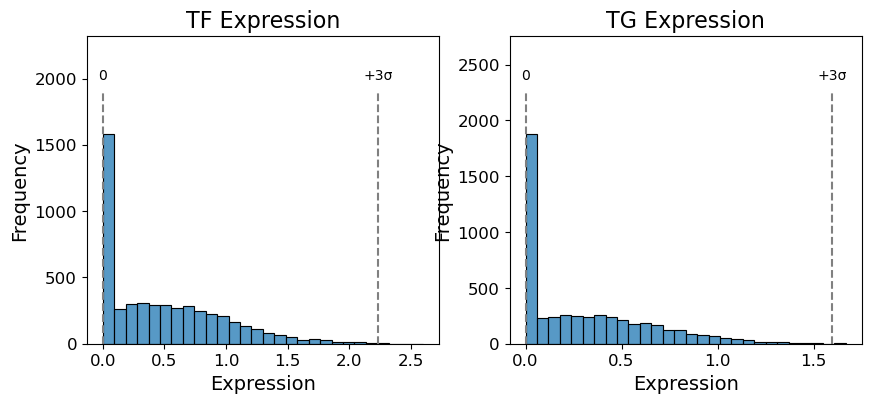

In [5]:
# TF and TG distribution information, cached for the scaler
tf_expression_mean = model.tf_expression_mean
tf_expression_std = model.tf_expression_std
tg_expression_mean = model.tg_expression_mean
tg_expression_std = model.tg_expression_std

def plot_expression_distribution(expression_dict):
    """
    Plot random samples from a normal distribution with a given mean and standard deviation.
    """
    rng = np.random.default_rng()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    for i, (title, values) in enumerate(expression_dict.items()):
        mean, std = values
        sns.histplot(rng.normal(mean, std, size=5000).clip(min=0), fill=True, ax=axes[i])
        
        max_ylim = max(axes[i].get_ylim())
        
        line_ylim = max_ylim + 0.15*max_ylim
        text_ylim = max_ylim + 0.20*max_ylim
        
        axes[i].vlines(0, 0, line_ylim, colors='gray', linestyles='dashed')
        axes[i].vlines(mean + 3*std, 0, line_ylim, colors='gray', linestyles='dashed')
        # plt.hlines(0.9, mean - 3*std, mean + 3*std, colors='red', linestyles='dashed')
        axes[i].text(0, text_ylim, "0", ha="center", fontsize=10)
        axes[i].text(mean + 3*std, text_ylim, "+3σ", ha="center", fontsize=10)
        axes[i].set_title(title, fontsize=16)
        axes[i].set_xlabel("Expression", fontsize=14)
        axes[i].set_ylabel("Frequency", fontsize=14)
        axes[i].set_ylim(0, max_ylim + 0.4*max_ylim)
        axes[i].tick_params(axis='both', which='major', labelsize=12)
    fig.show()
    
expression_dict = {
    "TF Expression": (tf_expression_mean, tf_expression_std),
    "TG Expression": (tg_expression_mean, tg_expression_std)
}
plot_expression_distribution(expression_dict)

Next, we project these values through the TF expression projection layer or the TG expression projection layer. This layer takes a scaler input and projects it to a 128 dimensional vector.

In [6]:
def project_expression(expression_layer, mean, std, device, num=1000):
    """
    Projects a range of values through the TF or TG expression dense layers, sampled using the scaler distribution.
    
    Creates a linear distribution of expression values using the mean and standard deviation
    from the expression scaler.
    """
    mean, std = float(mean), float(std)
    
    # Create a linear distribution of expression values
    # within 3 standard deviations of the mean using the scaler
    min = max(0, mean - 3 * std) # Ensure the minimum is not negative
    raw_values = np.linspace(min, mean + 3 * std, num=num)
    
    # Scale the raw values using the scaler
    scaled = (raw_values - mean) / std
    inputs = torch.as_tensor(scaled, dtype=torch.float32, device=device).unsqueeze(1)

    # Run the inputs through the model
    with torch.inference_mode():
        projected = expression_layer.to(device)(inputs).cpu().numpy()

    return projected, raw_values

 # Project a range of TF and TG expression values through their projection layers
tf_projected, tf_input_values = project_expression(model.tf_expr_proj, tf_expression_mean, tf_expression_std, device)
tg_projected, tg_input_values = project_expression(model.tg_expr_proj, tg_expression_mean, tg_expression_std, device)

/tmp/ipykernel_99398/670672356.py:417: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["1"], fontsize=12)


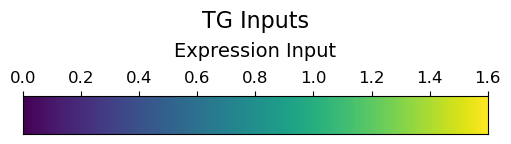

/tmp/ipykernel_99398/670672356.py:417: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["1"], fontsize=12)


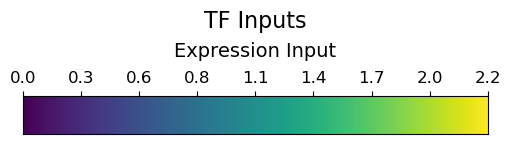

In [7]:
plot_single_row_heatmap(tg_input_values, tg_input_values, "TG Inputs")
plot_single_row_heatmap(tf_input_values, tf_input_values, "TF Inputs")

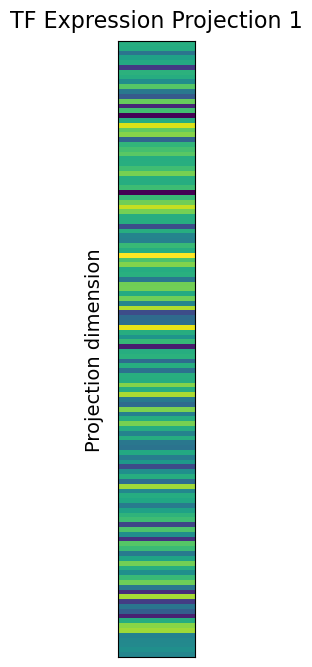

/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


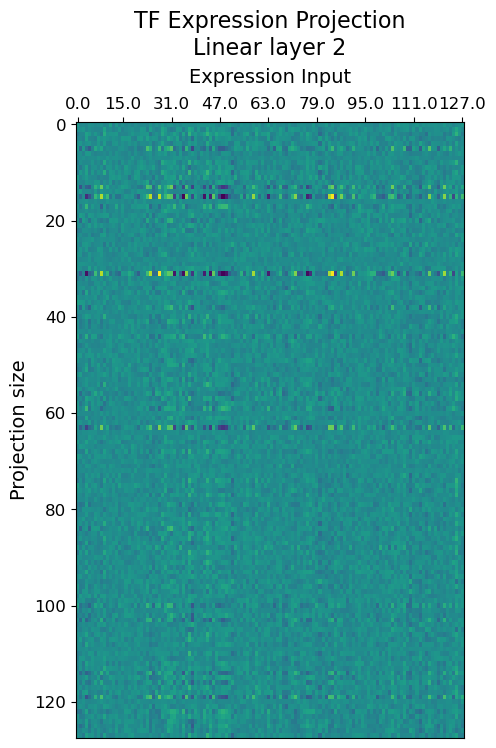

In [8]:
plot_single_column_heatmap(model.tf_expr_proj[0].weight, range(len(model.tf_expr_proj[0].weight)), "TF Expression Projection 1")

projection_dict = {
    "TF Expression Projection\nLinear layer 2": (model.tf_expr_proj[2].weight.detach().cpu().numpy(), range(len(model.tf_expr_proj[2].weight.detach().cpu().numpy()))),
}
plot_projected_expression(projection_dict)

/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)
/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


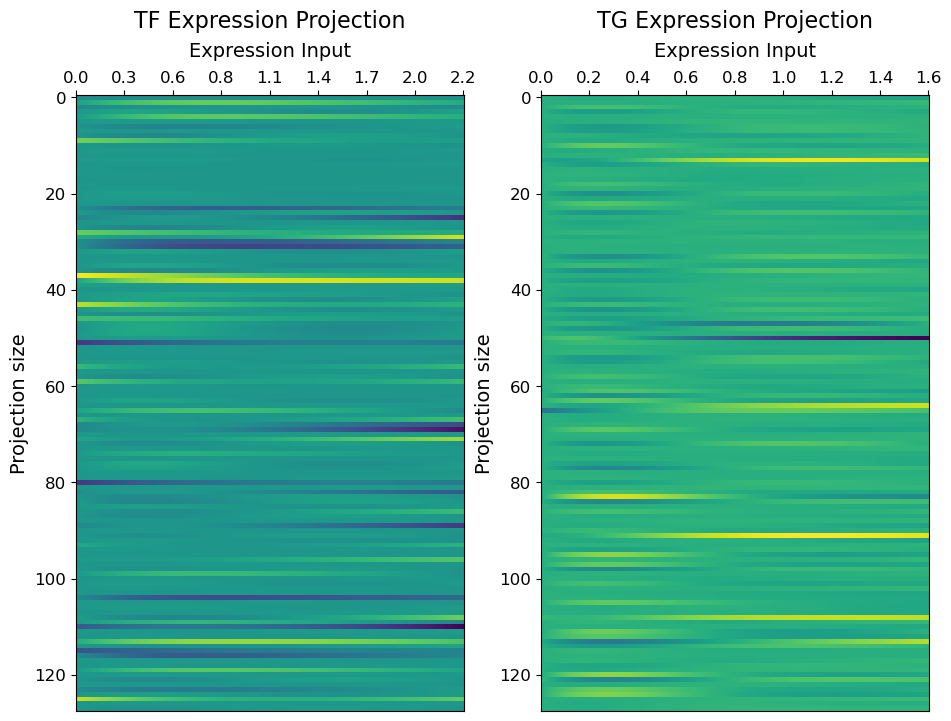

In [9]:

projection_dict = {
    "TF Expression Projection": (tf_projected, tf_input_values),
    "TG Expression Projection": (tg_projected, tg_input_values)
}
    
plot_projected_expression(projection_dict)

The output from the TF and TG expression projection layers are added and passed through another dense layer. The output from this layer is used as the input to the gene expression to peak cross-attention layer.

/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


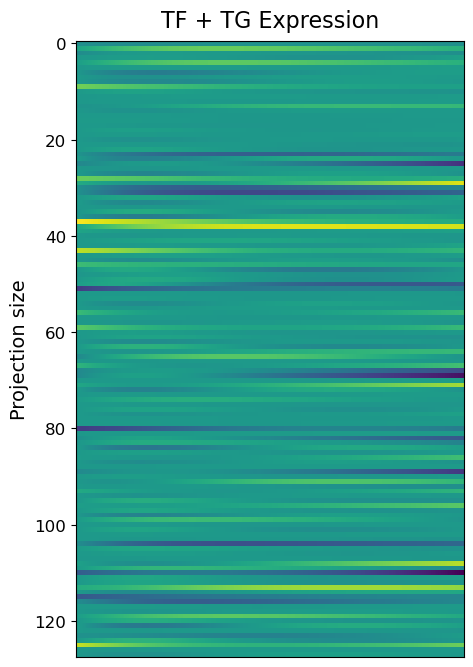

In [10]:
projection_dict = {"TF + TG Expression": (tf_projected + tg_projected, None)}
plot_projected_expression(projection_dict)


In [11]:
model.tg_query_proj

Sequential(
  (0): Linear(in_features=128, out_features=128, bias=True)
  (1): SiLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
)

In [12]:
model.tg_query_proj[0].weight.shape

torch.Size([128, 128])

/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)
/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


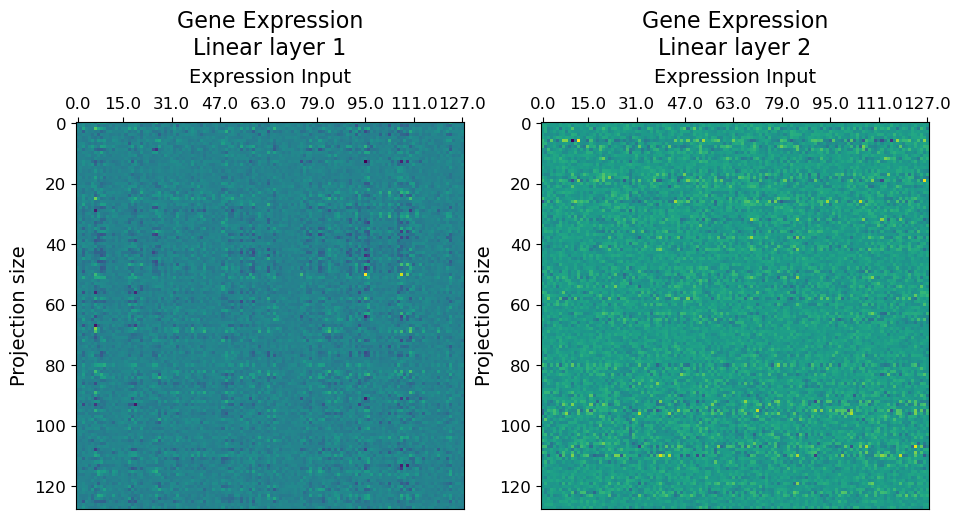

In [13]:
projection_dict = {
    "Gene Expression\nLinear layer 1": (model.tg_query_proj[0].weight.detach().cpu().numpy(), range(len(model.tg_query_proj[0].weight.detach().cpu().numpy()))),
    "Gene Expression\nLinear layer 2": (model.tg_query_proj[2].weight.detach().cpu().numpy(), range(len(model.tg_query_proj[2].weight.detach().cpu().numpy()))),
}
plot_projected_expression(projection_dict, keep_square=True)

In [14]:
tg_query_proj = model.tg_query_proj(torch.tensor(tf_projected) + torch.tensor(tg_projected))
tg_query_proj.shape

torch.Size([1000, 128])

/tmp/ipykernel_99398/670672356.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


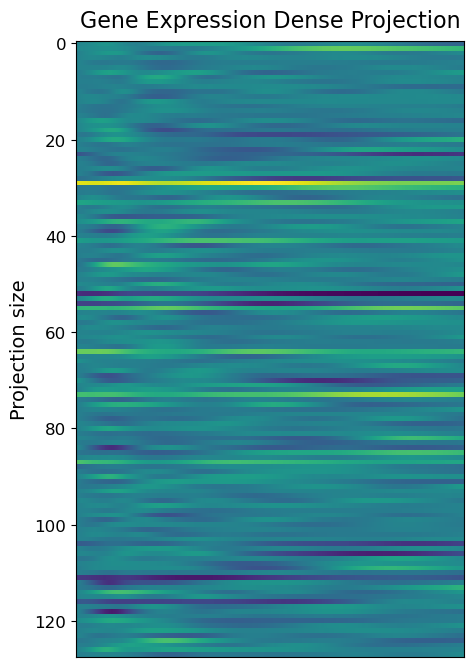

In [15]:
plot_projected_expression({"Gene Expression Dense Projection": (tg_query_proj, None)})

We can visualize how the output of the gene expression dense layer changes as we vary both the TF and TG inputs.

In [16]:
import plotly.graph_objects as go

def tg_query_grid(model_tg_query_proj, tf_projected, tg_projected,
                  device, batch_size=16):
    layer = model_tg_query_proj.to(device).eval()
    tf_tokens = torch.as_tensor(tf_projected, dtype=torch.float32, device=device)
    tg_tokens = torch.as_tensor(tg_projected, dtype=torch.float32, device=device)

    output_batches = []
    with torch.inference_mode():
        for start in range(0, len(tf_tokens), batch_size):
            tf_batch = tf_tokens[start:start + batch_size]
            pairs = tf_batch[:, None, :] + tg_tokens[None, :, :]
            out = layer(pairs.reshape(-1, pairs.shape[-1]))
            output_batches.append(
                out.reshape(len(tf_batch), len(tg_tokens), -1).cpu().numpy()
            )

    return np.concatenate(output_batches, axis=0)

tf_idx = np.linspace(0, len(tf_input_values) - 1, 40, dtype=int)
tg_idx = np.linspace(0, len(tg_input_values) - 1, 40, dtype=int)

grid = tg_query_grid(
    model.tg_query_proj,
    tf_projected[tf_idx],
    tg_projected[tg_idx],
    device,
)  # [40, 40, output features]


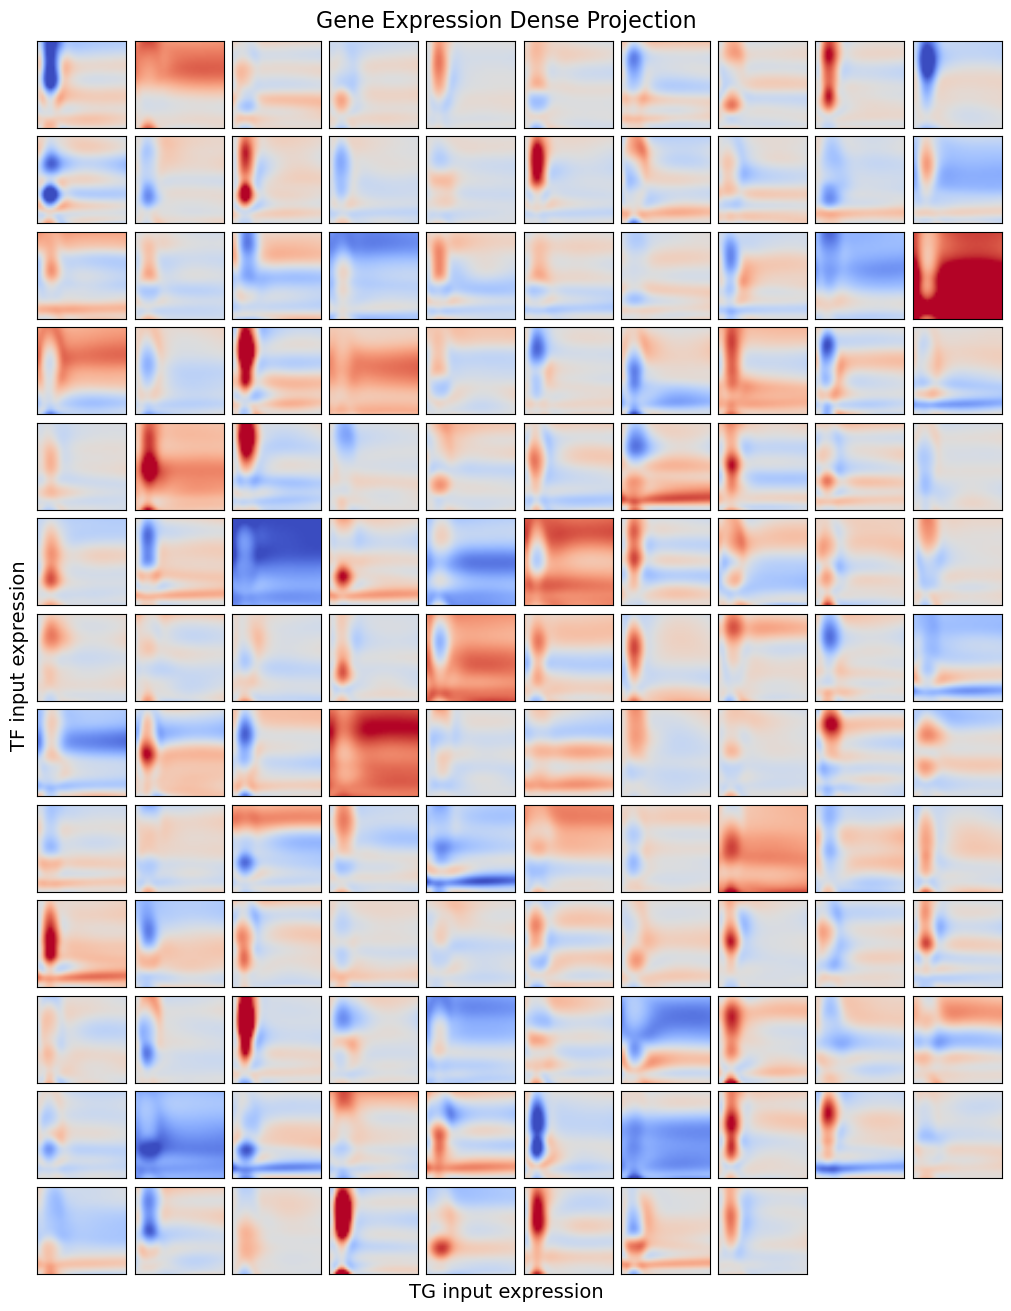

In [17]:
from matplotlib.colors import TwoSlopeNorm

num_features = grid.shape[-1]

cols = 10
rows = int(np.ceil(num_features / cols))

# Shared robust, symmetric color range across every feature.
vmax = np.quantile(np.abs(grid), 0.99)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(1 * cols, 1 * rows),
    sharex=True,
    sharey=True,
    squeeze=False,
    constrained_layout=True,
)

for i in range(num_features):
    row, col = divmod(i, cols)
    ax = axes[row, col]

    im = ax.imshow(
        grid[..., i],
        origin="lower",
        aspect="auto",
        extent=[
            tg_input_values[0],
            tg_input_values[-1],
            tf_input_values[0],
            tf_input_values[-1],
        ],
        cmap="coolwarm",
        norm=norm,
        interpolation="bilinear",
    )

    ax.set_xticks([])
    ax.set_yticks([])

# Remove unused panels in the final row.
for i in range(num_features, rows * cols):
    row, col = divmod(i, cols)
    axes[row, col].remove()

fig.supxlabel("TG input expression", fontsize=14)
fig.supylabel("TF input expression", fontsize=14)
fig.suptitle(
    "Gene Expression Dense Projection",
    fontsize=16,
)


plt.show()

In [18]:
import numpy as np
import plotly.graph_objects as go

feature_positions = np.linspace(
    0,
    grid.shape[-1] - 1,
    grid.shape[-1],
)

X, Y, Z = np.meshgrid(
    tf_input_values[tf_idx],
    tg_input_values[tg_idx],
    feature_positions,
    indexing="ij",
)

grid_min = grid.min()
grid_max = grid.max()

if np.isclose(grid_min, grid_max):
    raise ValueError("The grid is constant and cannot be min-max normalized.")

normalized_grid = (
    (grid - grid_min)
    / (grid_max - grid_min)
)

normalized_ticks = np.linspace(0, 1, 6)
original_ticks = grid_min + normalized_ticks * (grid_max - grid_min)

# Use a robust symmetric range so a few outliers do not dominate.
vmax = np.quantile(np.abs(grid), 0.99)
signed_grid = np.clip(grid, -vmax, vmax)

fig = go.Figure(go.Volume(
    x=X.ravel(),
    y=Y.ravel(),
    z=Z.ravel(),
    value=signed_grid.ravel(),

    # A symmetric domain puts zero exactly at 0.5 in opacityscale.
    isomin=-vmax,
    isomax=vmax,
    cmin=-vmax,
    cmax=vmax,
    cmid=0,

    surface_count=12,
    opacity=0.5,

    # Blue = negative, white = near zero, red = positive
    colorscale=[
        [0.00, "#2166ac"],
        [0.25, "#67a9cf"],
        [0.50, "#f7f7f7"],
        [0.75, "#ef8a62"],
        [1.00, "#b2182b"],
    ],

    caps=dict(
        x_show=False,
        y_show=False,
        z_show=False,
    ),

    colorbar=dict(
        title="Projection value",
        tickvals=np.linspace(-vmax, vmax, 5),
        ticktext=[
            f"{value:.2f}"
            for value in np.linspace(-vmax, vmax, 5)
        ],
    ),
))

fig.update_layout(
    scene=dict(
        xaxis_title="TF input expression",
        yaxis_title="TG input expression",
        zaxis_title="Projected feature index",
        aspectmode="manual", 
        aspectratio=dict(x=1, y=1, z=2.0)
    ),
    width=900,
    height=900,
)

fig.write_html(
    PROJECT_DIR / "activation_volume.html",
    include_plotlyjs=True,
    full_html=True,
)

### Peak Features

Next, we can look at the peak features. We first define a function that will load the peak features for one batch and stack them.

In [19]:
def prepare_peak_features(batch, model, device):
    accessibility = batch["peak_accessibility"].float().to(device)
    distance = batch["peak_distance"].float().to(device)
    binding = batch["binding_score"].float().to(device)
    peak_mask = batch["peak_mask"].bool().to(device)
    cell_mask = batch["cell_mask"].bool().to(device)

    B, C, P = accessibility.shape

    accessibility = (
        accessibility - model.peak_accessibility_mean
    ) / model.peak_accessibility_std

    valid = cell_mask[:, :, None] & peak_mask[:, None, :]
    accessibility = accessibility.masked_fill(~valid, 0)

    abs_distance = distance.abs()
    distance_scaled = (abs_distance / 250_000.0).clamp(0, 1)
    distance_weight = torch.exp(-abs_distance / 50_000.0)

    binding = binding.masked_fill(~peak_mask, 0)
    distance_scaled = distance_scaled.masked_fill(~peak_mask, 0)
    distance_weight = distance_weight.masked_fill(~peak_mask, 0)

    peak_features = torch.stack(
        [
            binding[:, None, :].expand(B, C, P),
            accessibility,
            distance_scaled[:, None, :].expand(B, C, P),
            distance_weight[:, None, :].expand(B, C, P),
        ],
        dim=-1,
    )

    return peak_features.reshape(B * C, P, 4)

Next, we load the first batch from the test dataloader and prepare the peak features. The shape of the peak features will be `[batch_size * n_cells, n_peaks, 4]`.

In [20]:
first_batch = next(iter(test_dataloader))
first_batch_peak_features = prepare_peak_features(first_batch, model, device)

print(f"Batch Size: {first_batch['cell_indices'].shape[0]}")
print(f"Cell Count: {first_batch['cell_indices'].shape[1]}")
print(f"Number of Peak Features: {first_batch['peak_indices'].shape[1]}")
print(f"\nPeak Features Shape: {first_batch_peak_features.shape}")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 24 worker processes in total. Our suggested max number of worker in current system is 10, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Batch Size: 512
Cell Count: 25
Number of Peak Features: 25

Peak Features Shape: torch.Size([12800, 25, 4])


The cells and peaks contain masks to keep the shapes the same for edges and cells with different numbers of peaks. We select only the unmasked portions of the peak features.

In [21]:
feature_names = [
    "binding_predictions",    # Peak feature 0
    "accessibility",          # Peak feature 1
    "distance_values",        # Peak feature 2
    "distance_weight",        # Peak feature 3
]

valid = (
    first_batch["cell_mask"].bool()[:, :, None] # (B, C, None)
    & first_batch["peak_mask"].bool()[:, None, :] # (B, None, P)
).reshape(-1) # (B, C, P) -> (B * C * P)

# Reshape peak features from (B*C, P, 4) to (B * C * P, 4) and filter by valid combinations
valid_features = first_batch_peak_features.reshape(-1, 4)[valid.to(device)]
valid_features = valid_features.cpu().numpy()

In [22]:
(
    first_batch["cell_mask"].bool()[:, :, None] # (B, C, None)
    & first_batch["peak_mask"].bool()[:, None, :] # (B, None, P)
).shape

torch.Size([512, 25, 25])

Next, we create linear distributions for each of the peak inputs like we did for the expression data. These are combined into a meshgrid that we can use to run predictions for every combination. The grid values are stacked as inputs to the model.

In [23]:
# Observed input ranges from the valid (cell, peak) entries of the first batch.
binding_obs = valid_features[:, 0]
access_obs = valid_features[:, 1]

peak_mask_np = first_batch["peak_mask"].bool().numpy()
abs_distance_obs = first_batch["peak_distance"].float().abs().numpy()[peak_mask_np]

n_values = 25
axes_values = {
    "binding_predictions": np.linspace(binding_obs.min(), binding_obs.max(), n_values, dtype=np.float32),
    "accessibility": np.linspace(access_obs.min(), access_obs.max(), n_values, dtype=np.float32),
    "abs_distance": np.linspace(0, abs_distance_obs.max(), n_values, dtype=np.float32),
}
grid_names = list(axes_values)

binding_g, access_g, dist_g = np.meshgrid(
    *(axes_values[name] for name in grid_names), indexing="ij"
)

# Same distance transforms as SimpleTFTGRegulationModel.forward().
distance_scaled_g = np.clip(dist_g / 250_000.0, 0, 1)
distance_weight_g = np.exp(-dist_g / 50_000.0)

inputs = np.stack(
    [binding_g.ravel(), access_g.ravel(), distance_scaled_g.ravel(), distance_weight_g.ravel()],
    axis=1,
).astype(np.float32)  # [n_values**3, 4], column order matches peak_feature_proj
inputs.shape


(15625, 4)

Next, we run the peak feature inputs through the model's peak feature projection.

In [24]:
model.eval().to(device)
output_batches = []

with torch.inference_mode():
    for start in range(0, len(inputs), 4096):
        batch = torch.from_numpy(inputs[start:start + 4096]).to(device)
        output_batches.append(model.peak_feature_proj(batch).cpu().numpy())

# Concatenate the output batches and reshape
outputs = np.concatenate(output_batches, axis=0)
print("Output shape increases from 4 -> 128")
print(outputs.shape)

# Reshape the outputs so each dimension corresponds to a feature
outputs = outputs.reshape(n_values, n_values, n_values, -1)
outputs.shape

Output shape increases from 4 -> 128
(15625, 128)


(25, 25, 25, 128)

/tmp/ipykernel_99398/670672356.py:417: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["1"], fontsize=12)


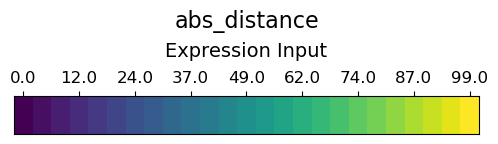

In [25]:
plot_single_row_heatmap(axes_values[grid_names[2]], axes_values[grid_names[2]]//1000, grid_names[2])


Next, we can visualize how the output changes depending on just one feature at a time by averaging over the combinations of the other two features. We can then plot a heatmap for how the output changes as the input feature value changes. 

In [56]:
model.peak_feature_proj

Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): SiLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=128, out_features=128, bias=True)
)

In [66]:
model.peak_feature_proj[0].weight.shape

torch.Size([128, 4])

/tmp/ipykernel_99398/1795122683.py:495: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)
/tmp/ipykernel_99398/1795122683.py:495: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


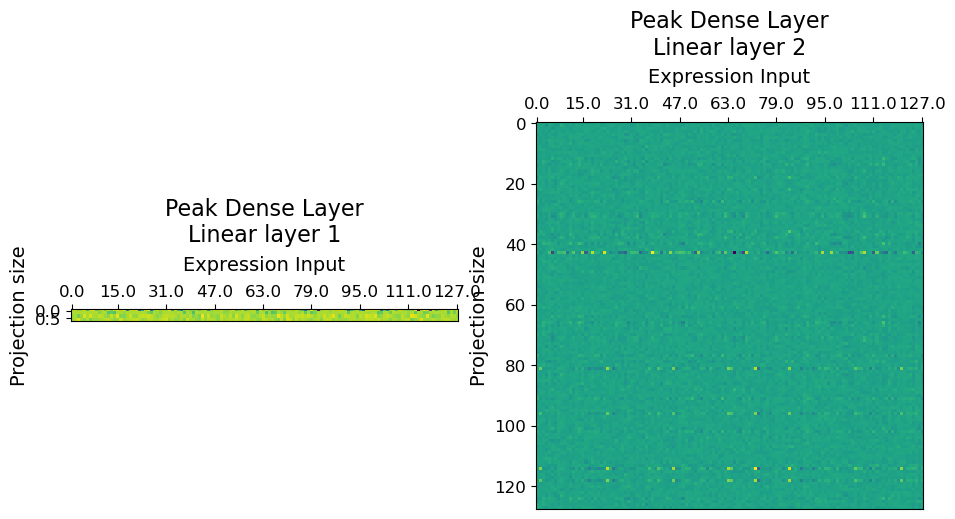

In [69]:
projection_dict = {
    "Peak Dense Layer\nLinear layer 1": (model.peak_feature_proj[0].weight.detach().cpu().numpy(), range(len(model.peak_feature_proj[0].weight.detach().cpu().numpy()))),
    "Peak Dense Layer\nLinear layer 2": (model.peak_feature_proj[3].weight.detach().cpu().numpy(), range(len(model.peak_feature_proj[3].weight.detach().cpu().numpy()))),
}
plot_projected_expression(projection_dict, keep_square=True)

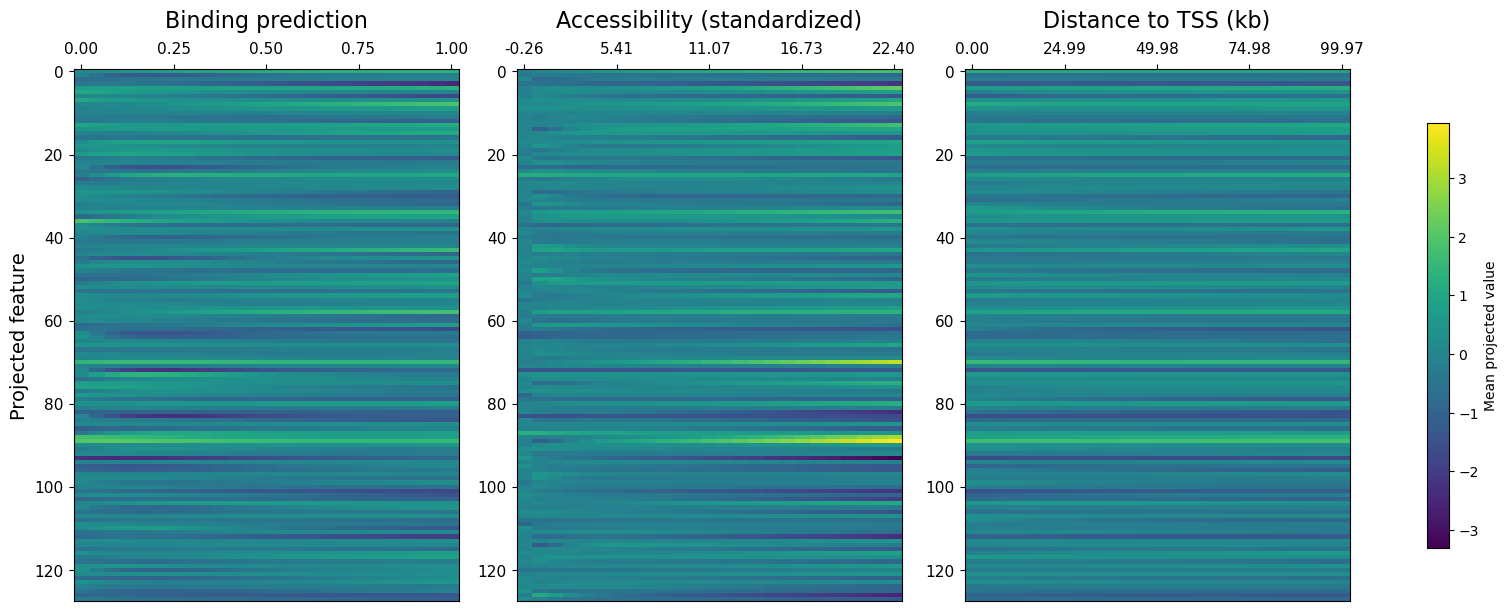

In [26]:
# For each input, average projections across all combinations
# of the other three inputs. Result: [input values, projected features].
marginal_projections = {
    name: outputs.mean(axis=tuple(j for j in range(3) if j != i))
    for i, name in enumerate(grid_names)
}

plot_names = grid_names
labels = ["Binding prediction", "Accessibility (standardized)", "Distance to TSS (kb)"]
tick_scale = {"abs_distance": 1e-3}  # bp -> kb for the tick labels only

fig, axs = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)

# Shared color scale makes the three heatmaps comparable.
vmin = min(marginal_projections[name].min() for name in plot_names)
vmax = max(marginal_projections[name].max() for name in plot_names)


for ax, name, label in zip(axs, plot_names, labels):
    data = marginal_projections[name].T
    values = axes_values[name]

    im = ax.imshow(
        data,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    ticks = np.linspace(0, len(values) - 1, 5, dtype=int)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{values[i] * tick_scale.get(name, 1):.2f}" for i in ticks], fontsize=11)

    ax.set_title(label, fontsize=16, pad=10)
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", top=True, labeltop=True,
                   bottom=False, labelbottom=False, pad=6)
    ax.tick_params(axis="y", labelsize=11)

axs[0].set_ylabel("Projected feature", fontsize=14)
fig.colorbar(im, ax=axs, label="Mean projected value", shrink=0.8)
plt.show()

## Attention Layer

Next, we can see how changes to the TG expression input will alter the attention patterns for a set of peak inputs. First, we will select the first cell with a valid mask:

In [83]:
# Get the first batch and select one cell
edge_num = 0
cell_num = 0
B, C = first_batch["cell_mask"].shape
valid_cell_idx = first_batch["cell_mask"][edge_num].bool().nonzero()[cell_num, 0].item() # Cell index

print(f"Sample: {first_batch['sample_id'][edge_num]}")
print(f"Cell Type: {first_batch['cell_type'][edge_num]}")
print(f"TF: {first_batch['tf_name'][edge_num]}")
print(f"TG: {first_batch['tg_id'][edge_num]}")
print(f"Selected cell index: {valid_cell_idx}")

Sample: E7.5_rep1
Cell Type: Neurectoderm
TF: SOX2
TG: LAMA3
Selected cell index: 0


Next, we select the peak features for the cell and project them through the peak feature projection layer

In [84]:
print(f"Reference features shape: {first_batch_peak_features.shape}")
# Reshape the reference features to be [B, C, num_peaks, 4]
# Select the features for the chosen cell in the first edge [num_peaks, 4]
reference_features = first_batch_peak_features.reshape(B, C, -1, 4)[0, valid_cell_idx]
print(f"Reference features shape first cell: {reference_features.shape}")

# Apply the peak mask to only get the applicable peaks for the chosen cell
reference_mask = first_batch["peak_mask"][0].bool().to(device)
reference_features = reference_features[reference_mask]
print(f"Reference features shape after masking: {reference_features.shape}")

# Project the reference features into the model's embedding space
reference_tokens = model.peak_feature_proj(reference_features)
print(f"Reference tokens shape: {reference_tokens.shape}")

Reference features shape: torch.Size([12800, 25, 4])
Reference features shape first cell: torch.Size([25, 4])
Reference features shape after masking: torch.Size([25, 4])
Reference tokens shape: torch.Size([25, 128])


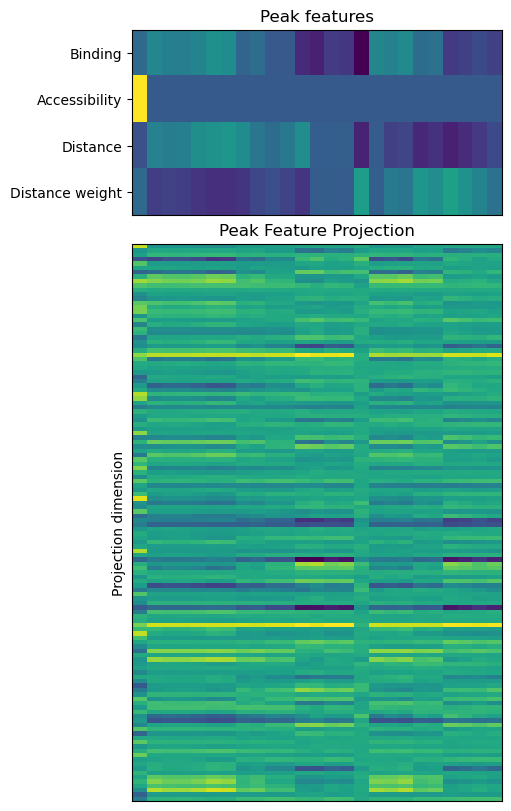

In [85]:
from scipy.cluster.hierarchy import linkage, leaves_list

# reference_features: [candidates, 4]
# reference_tokens:   [candidates, d_model]
raw_features = np.asarray(reference_features.cpu().numpy())
peak_tokens = reference_tokens.detach().cpu().numpy()

# Standardize columns for display only; the model used the original values.
feature_mean = raw_features.mean(axis=0, keepdims=True)
feature_std = raw_features.std(axis=0, keepdims=True)
display_features = (raw_features - feature_mean) / np.maximum(feature_std, 1e-8)

# cluster the raw features
order = leaves_list(linkage(display_features, method="average"))

fig, axs = plt.subplots(
    2, 1, figsize=(5, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 3]},
)

im0 = axs[0].imshow(
    display_features[order].T, aspect="auto", interpolation="nearest", cmap="viridis"
)
axs[0].set_yticks(range(4))
axs[0].set_yticklabels(
    ["Binding", "Accessibility", "Distance", "Distance weight"],
    rotation=0, ha="right",
)
axs[0].set_title("Peak features")

im1 = axs[1].imshow(
    peak_tokens[order].T, aspect="auto", interpolation="nearest", cmap="viridis"
)
axs[1].set_ylabel("Projection dimension")
axs[1].set_title("Peak Feature Projection")
axs[1].set_yticks([])
axs[1].set_yticklabels([])
axs[1].set_xticks([])
axs[1].set_xticklabels([])


plt.show()

We will use the output from the TG expression projection layer from before while holding the TF expression input at its mean (0, since it's normalized).

In [86]:
# The range of projected TG expression values from before
tg_tokens = torch.tensor(tg_projected.copy(), device=device)
print(tg_tokens.shape)

# Project the mean TF expression (0) through the TF expression projection layer
mean_tf_expr = torch.tensor([tf_input_values.mean()], dtype=torch.float32, device=device)
tf_tokens = model.tf_expr_proj(mean_tf_expr).unsqueeze(0)
print(tf_tokens.shape)

torch.Size([1000, 128])
torch.Size([1, 128])


The input to the attention layer is the addition of the TF and TG tokens

In [87]:
model.to(device)
queries = model.tg_query_proj(tf_tokens + tg_tokens)
print(queries.shape)

torch.Size([1000, 128])


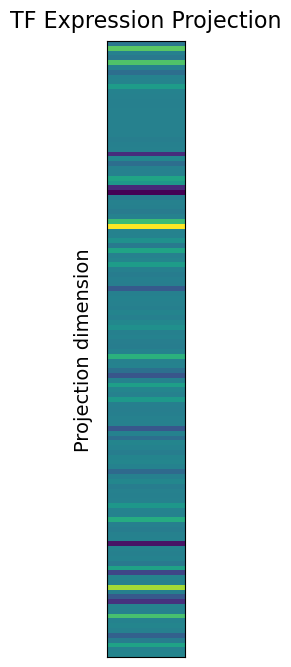

In [88]:
plot_single_column_heatmap(tf_tokens.T, range(tf_tokens.shape[0]), "TF Expression Projection")

/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)
/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


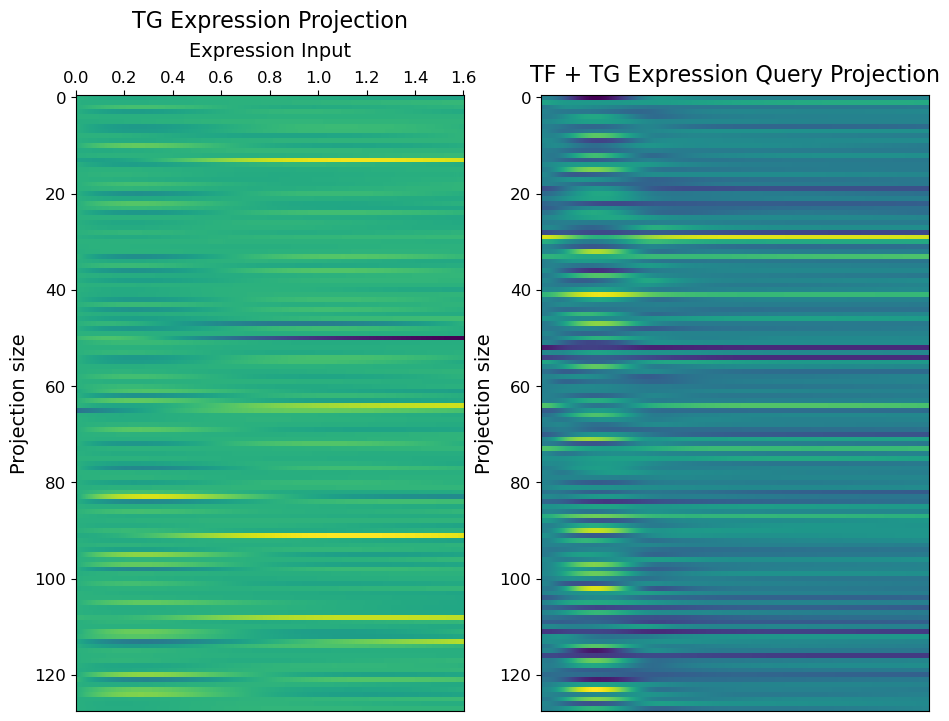

In [89]:
projection_dict = {
    "TG Expression Projection": (tg_tokens.detach().cpu().numpy(), tg_input_values),
    "TF + TG Expression Query Projection": (queries.detach().cpu().numpy(), None),
}

plot_projected_expression(projection_dict)

Next, we will run the gene-peak cross-attention layer using the summed TF and TG expression projection as the input to the query projection and the cell's peak feature projection as the  inputs to the key and value projections. The Key, Query, and Value vectors are generated by multiplying the inputs by separate learned weight matrices.

$$Q = XW_{Q} + b_{Q}$$
$$K = XW_{K} + b_{k}$$
$$V = XW_{V} + b_{V}$$

Where:

$$W_{Q} \in \mathbb{R}^{d_{model}\times d_{k}}$$
$$W_{K} \in \mathbb{R}^{d_{model}\times d_{k}}$$
$$W_{V} \in \mathbb{R}^{d_{model}\times d_{v}}$$

As we are using multi-head attention, $d_{k} = d_{v} = d_{model}/H$, where $H$ is the number of heads.

In [90]:
import torch.nn.functional as F

attention = model.peak_attention
d_model = attention.embed_dim
n_heads = attention.num_heads
head_dim = d_model // n_heads
print(f"Model dimensions: d_model={d_model}, n_heads={n_heads}, head_dim={head_dim}")

# Keep the same input-feature cluster order used in your other plots.
tokens = reference_tokens[torch.as_tensor(order, device=device)]

# Learned QKV weights and biases from the attention mechanism
W_q, W_k, W_v = attention.in_proj_weight.split(d_model, dim=0)
b_q, b_k, b_v = attention.in_proj_bias.split(d_model, dim=0)
print(f"\nLearned QKV weights and biases shapes:")
print(f"  - Weights: Q={W_q.shape}, K={W_k.shape}, V={W_v.shape}")
print(f"  - Biases: Q={b_q.shape}, K={b_k.shape}, V={b_v.shape}")

print(f"\nInput feature shapes:")
print(f"  - Queries (gene expression): {queries.shape}")
print(f"  - Key/Value (peak information): {tokens.shape}")

# Project the query, key, and value vectors through the learned projections.
with torch.inference_mode():
    queries_proj = F.linear(queries, W_q, b_q).cpu().numpy()  # [TG values, 128]
    key_proj = F.linear(tokens, W_k, b_k).cpu().numpy()       # [peaks, 128]
    value_proj = F.linear(tokens, W_v, b_v).cpu().numpy()     # [peaks, 128]

print(f"\nProjected feature shapes:")
print(f"  - Queries: {queries_proj.shape}")
print(f"  - Key: {key_proj.shape}")
print(f"  - Value: {value_proj.shape}")

Model dimensions: d_model=128, n_heads=4, head_dim=32

Learned QKV weights and biases shapes:
  - Weights: Q=torch.Size([128, 128]), K=torch.Size([128, 128]), V=torch.Size([128, 128])
  - Biases: Q=torch.Size([128]), K=torch.Size([128]), V=torch.Size([128])

Input feature shapes:
  - Queries (gene expression): torch.Size([1000, 128])
  - Key/Value (peak information): torch.Size([25, 128])

Projected feature shapes:
  - Queries: (1000, 128)
  - Key: (25, 128)
  - Value: (25, 128)


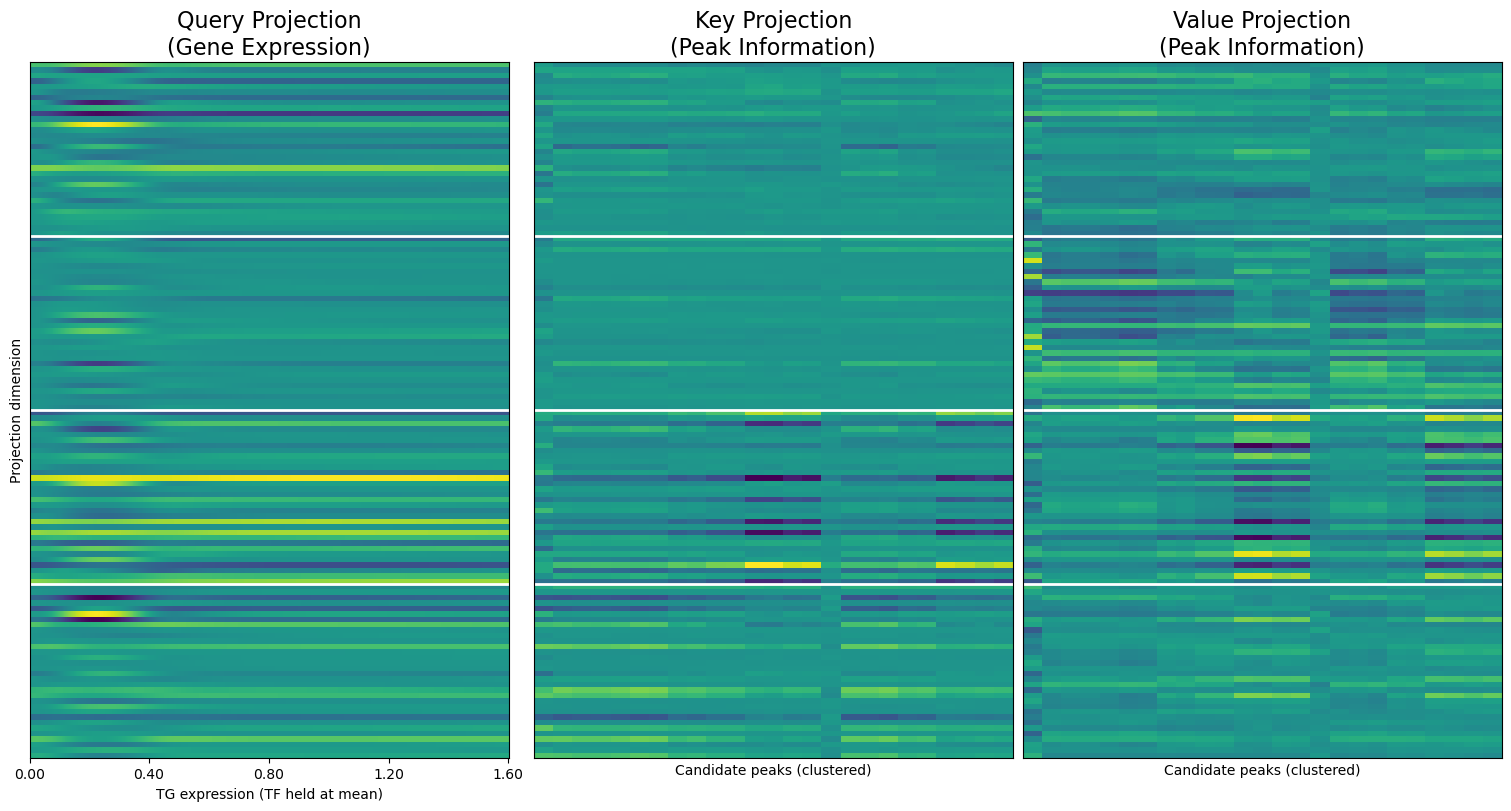

In [91]:
fig, axs = plt.subplots(
    1, 3,
    figsize=(15, 8),  # three 5 × 8 panels
    sharey=True,
    constrained_layout=True,
)

for ax, data, title in zip(
    axs,
    [queries_proj, key_proj, value_proj],
    [
        "Query Projection\n(Gene Expression)", 
        "Key Projection\n(Peak Information)", 
        "Value Projection\n(Peak Information)"
        ],
):
    ax.imshow(
        data.T,  # [projection dimensions, TG values or candidate peaks]
        aspect="auto",
        interpolation="nearest",
        cmap="viridis"
    )

    for boundary in range(head_dim, d_model, head_dim):
        ax.axhline(boundary - 0.5, color="white", linewidth=2)

    ax.set_title(title, fontsize=16)
    ax.set_yticks([])

query_ticks = np.linspace(0, len(tg_input_values) - 1, 5, dtype=int)
axs[0].set_xticks(query_ticks)
axs[0].set_xticklabels([f"{tg_input_values[i]:.2f}" for i in query_ticks])
axs[0].set_xlabel("TG expression (TF held at mean)")
axs[0].set_ylabel("Projection dimension")

for ax in axs[1:]:
    ax.set_xlabel("Candidate peaks (clustered)")
    ax.set_xticks([])

plt.show()

Next, the query and value matrices are compared to each other by taking the dot product between the keys and the transposed queries. This produces a similarity matrix between each element in the keys and queries which is used to weigh the value matrix. These are scaled by the square root of the head dimension to keep the scores stable for larger models, then passed through the softmax function to create a probability where the most similar elements are weighted strongly.

$$\text{A}_{\text{h}} = \text{softmax}(\frac{Q_{h}K_{h}^T}{\sqrt{\text{d}_{k}}})$$

The attention weights of each head are then multiplied by the value vectors for that head.

$$O_{h} = A_{h}V_{h}$$

The separate head outputs are then concatenated and passed through an output projection.

$$O = \text{Concat}(O_{1},...,O_{H})W_{O}$$

In [92]:
from scipy.special import softmax

print("We add the head dimension to the projected features.")
# [TG values, heads, dimensions per head]
Q = queries_proj.reshape(len(tg_input_values), n_heads, head_dim)
print(f"  - Q: {Q.shape}")

# [peaks, heads, dimensions per head]
K = key_proj.reshape(len(tokens), n_heads, head_dim)
print(f"  - K: {K.shape}")

# [peaks, heads, dimensions per head]
V = value_proj.reshape(len(tokens), n_heads, head_dim)
print(f"  - V: {V.shape}")

# Multiply Q and K to get attention scores
# [TG values, heads, dimensions], [peaks, heads, dimensions] -> [heads, TG values, peaks]
# einsum multiplies along the shared dimension 'd', keeping 'h', 't', and 'p' dimensions
print(f"\nNext, we compute the dot product similarity between Q and K.")
dot_prod_similarity = np.einsum("thd,phd->htp", Q, K) / np.sqrt(K.shape[-1]) # scale by sqrt of K's head dimension
print(f"  - Dot product similarity: {dot_prod_similarity.shape}")

print(f"\nThen, we compute the attention weights using softmax.")
# Each head has a TG x peak attention matrix with values representing the attention
# between each TG and each peak
attention_weights = softmax(dot_prod_similarity, axis=-1) # (heads, TG values, peaks)
print(f"  - Attention weights: {attention_weights.shape}")

print("\nFinally, we compute the attention scores by multiplying the ")
print("attention weights with the value vectors.")
# This brings back the head dimension, resulting in a tensor of shape 
# (heads, TG values, dimensions per head)
# Note that the resulting tensor has the same dimensions as the Query vector.
attention_scores = np.einsum("htp,phd->htd", attention_weights, V)
print(f"  - Attention scores: {attention_scores.shape}")

# Concatenate the attention scores along the dimension of the heads.
# This collapses the head dimension, resulting in a tensor of shape (TG values, d_model).
print("\nThe attention scores are concatenated along the head dimension.")
concatenated_output = np.concatenate(attention_scores, axis=-1) 
print(f"  - Concatenated output: {concatenated_output.shape}")

# Project through linear layer
print("\nAnd finally, the concatenated output is projected through a linear layer.")
concat_out_tensor = torch.tensor(concatenated_output, dtype=torch.float32).to(device)
attention_output = model.peak_attention.out_proj(concat_out_tensor).cpu().detach().numpy()
print(f"Attention output: {attention_output.shape}")

We add the head dimension to the projected features.
  - Q: (1000, 4, 32)
  - K: (25, 4, 32)
  - V: (25, 4, 32)

Next, we compute the dot product similarity between Q and K.
  - Dot product similarity: (4, 1000, 25)

Then, we compute the attention weights using softmax.
  - Attention weights: (4, 1000, 25)

Finally, we compute the attention scores by multiplying the 
attention weights with the value vectors.
  - Attention scores: (4, 1000, 32)

The attention scores are concatenated along the head dimension.
  - Concatenated output: (1000, 128)

And finally, the concatenated output is projected through a linear layer.
Attention output: (1000, 128)


Just to test that the manual implementation mirrors what the model is doing, we can check that our calculation matches the model's output.

In [93]:
with torch.inference_mode():
    ref_out, _ = model.peak_attention(
        query=queries.unsqueeze(1),
        key=reference_tokens.unsqueeze(0).expand(len(queries), -1, -1),
        value=reference_tokens.unsqueeze(0).expand(len(queries), -1, -1),
        need_weights=False,
    )
# Check that the attention scores are relatively close to what the model outputs directly
np.testing.assert_allclose(attention_output, ref_out[:, 0].cpu().numpy(), rtol=1e-2, atol=1e-2)


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Text(0, 0.5, 'Peak index')

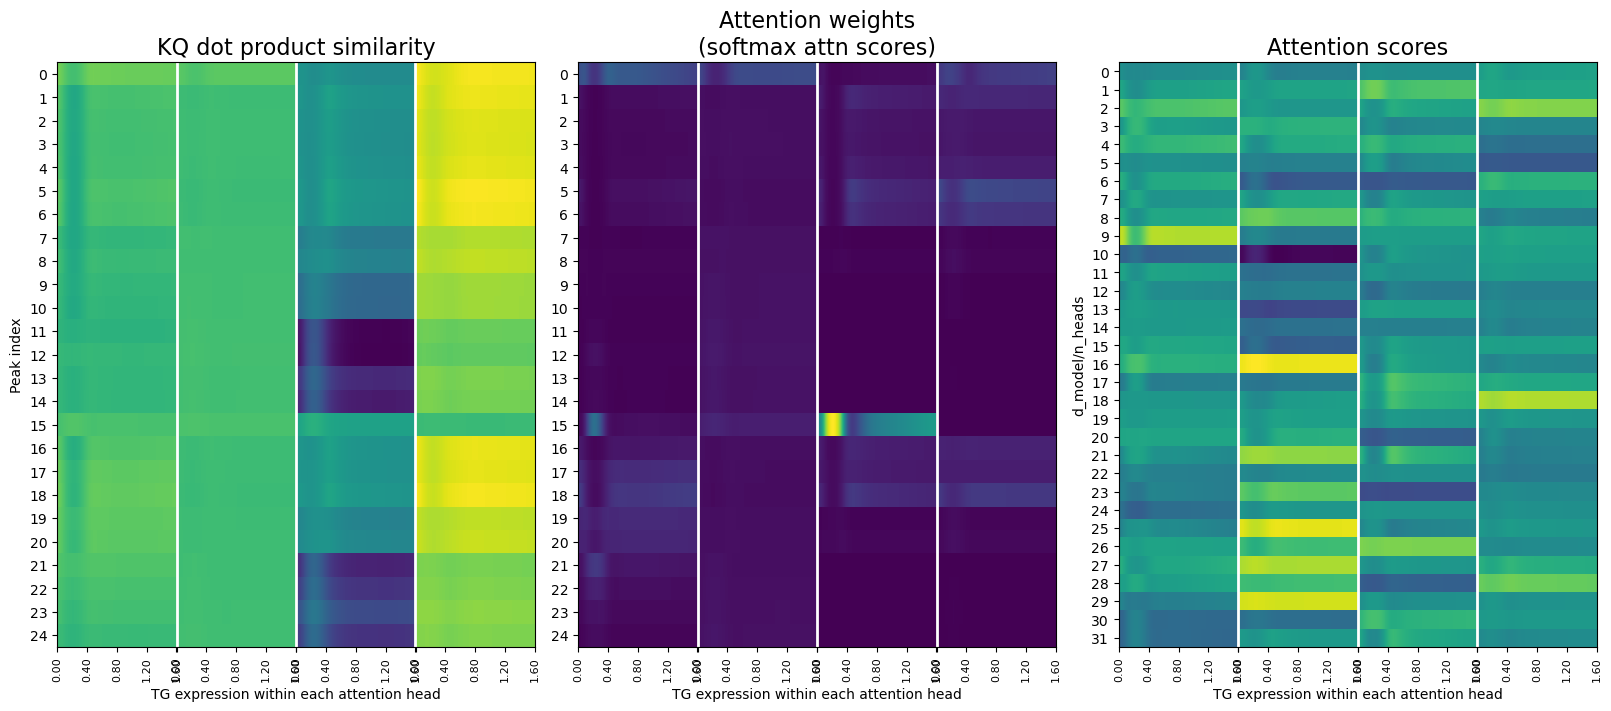

In [94]:
n_heads, n_tg_values, n_peaks = dot_prod_similarity.shape

flat_scores = dot_prod_similarity.reshape(n_heads * n_tg_values, n_peaks,)

flat_weights = attention_weights.reshape(n_heads * n_tg_values, n_peaks,)

flat_attention = attention_scores.reshape(n_heads * n_tg_values, -1)

score_plot = flat_scores.T
weight_plot = flat_weights.T
attention_plot = flat_attention.T


# [n_peaks, n_heads * n_tg_values]

score_min = score_plot.min()
score_max = score_plot.max()

score_plot_normalized = ((score_plot - score_min)/ (score_max - score_min))

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16, 7),
    sharex=True,
    sharey=False,
    constrained_layout=True,
)

for ax, data, title in zip(
    axs,
    [score_plot_normalized, weight_plot, attention_plot],
    ["KQ dot product similarity", "Attention weights\n(softmax attn scores)", "Attention scores"],
):
    print(type(data))
    im = ax.imshow(
        data,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
    )

    # Head boundaries occur along the x-axis.
    for boundary in range(
        n_tg_values,
        n_heads * n_tg_values,
        n_tg_values,
    ):
        ax.axvline(
            boundary - 0.5,
            color="white",
            linewidth=2,
        )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("TG expression within each attention head")
    
    local_ticks = np.linspace(
        0,
        n_tg_values - 1,
        5,
    ).round().astype(int)

    tick_positions = []
    tick_labels = []

    for head in range(n_heads):
        offset = head * n_tg_values

        tick_positions.extend(offset + local_ticks)
        tick_labels.extend([
            f"{tg_input_values[i]:.2f}"
            for i in local_ticks
        ])

    for ax in axs:
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(
            tick_labels,
            rotation=90,
            fontsize=8,
        )

        if ax == axs[0] or ax == axs[1]:
            ax.set_yticks(np.arange(n_peaks))
            ax.set_yticklabels(np.arange(n_peaks))
        elif ax == axs[2]:
            ax.set_yticks(np.arange(d_model//n_heads))
            ax.set_yticklabels(np.arange(d_model//n_heads))
            ax.set_ylabel("d_model/n_heads")

axs[0].set_ylabel("Peak index")

/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


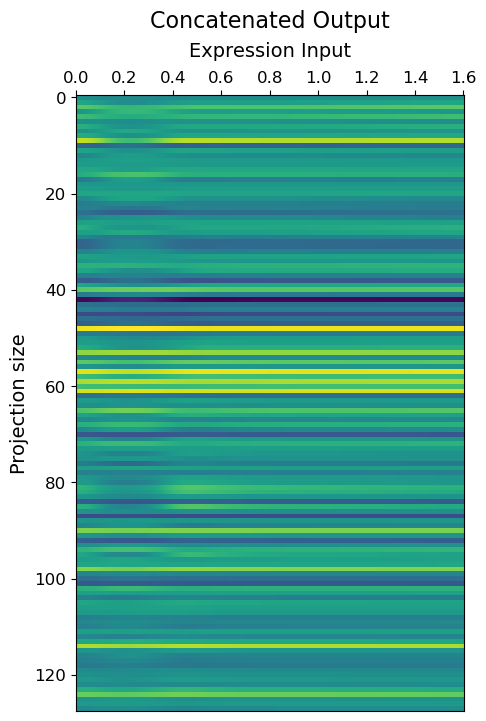

In [95]:
projection_dict = {
    "Concatenated Output": (concatenated_output, tg_input_values)
}
plot_projected_expression(projection_dict)

/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)
/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


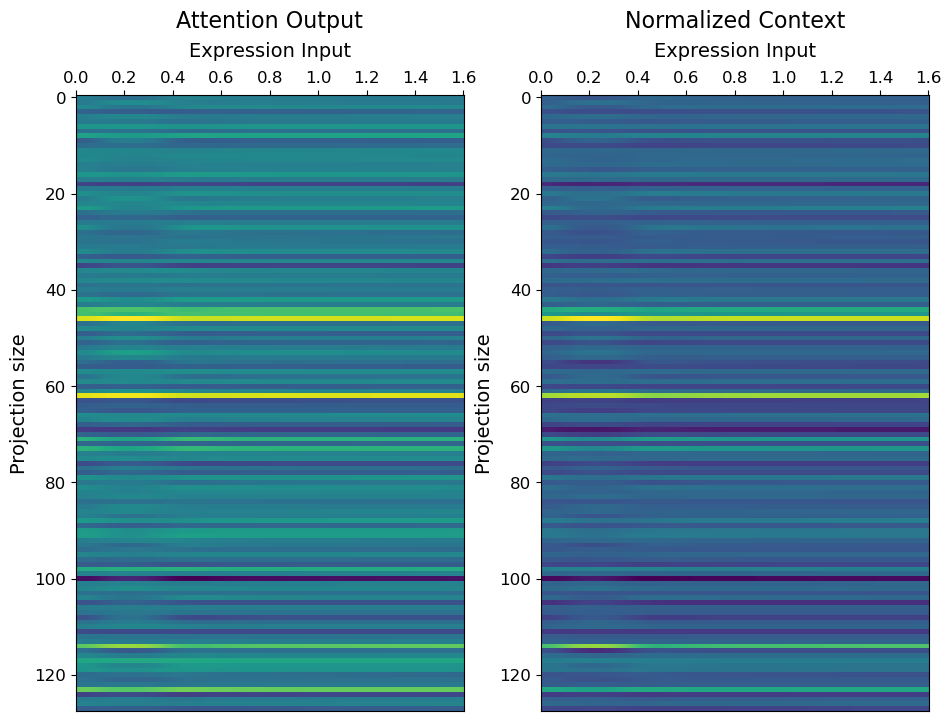

In [96]:
attention_output_norm = model.norm(torch.as_tensor(attention_output, device=device))

projection_dict = {
    "Attention Output": (attention_output, tg_input_values),
    "Normalized Context": (attention_output_norm.cpu().detach().numpy(), tg_input_values),
    }
plot_projected_expression(projection_dict)

### Final Classifier Layer

The output from the cross-attention layer, the TF expression projection, and TG expression projection are concatenated and passed into the classifier.

In [97]:
attention_output_tensor_norm = attention_output_norm.detach()
tf_token_tensor = tf_tokens.expand(len(tg_tokens), -1).to(device) # expand to match num TG values
tg_token_tensor = tg_tokens.to(device)
print(f"Attention Output Shape: {attention_output_tensor_norm.shape}")
print(f"TF Token Shape: {tf_token_tensor.shape}")
print(f"TG Token Shape: {tg_token_tensor.shape}")

features = torch.cat([attention_output_tensor_norm, tf_token_tensor, tg_token_tensor], dim=-1)
print(features.shape)

Attention Output Shape: torch.Size([1000, 128])
TF Token Shape: torch.Size([1000, 128])
TG Token Shape: torch.Size([1000, 128])
torch.Size([1000, 384])


/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


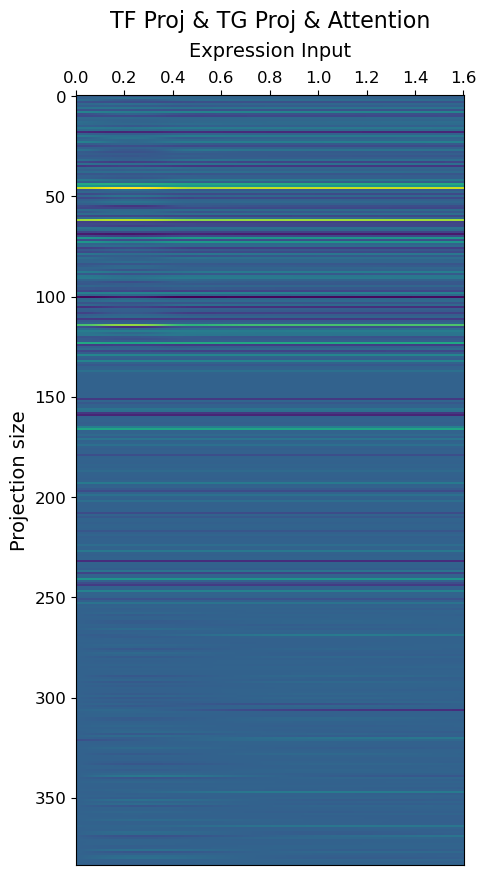

In [98]:
projection_dict = {
    "TF Proj & TG Proj & Attention": (features.detach().cpu().numpy(), tg_input_values),
    }
plot_projected_expression(projection_dict, height=10)

In [43]:
model.classifier

Sequential(
  (0): Linear(in_features=384, out_features=128, bias=True)
  (1): SiLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): SiLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
)

/tmp/ipykernel_99398/1217174604.py:493: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=12)


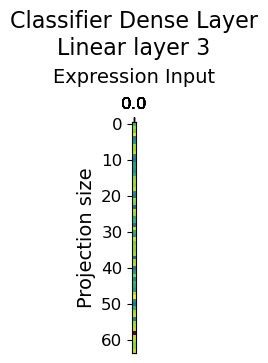

In [103]:
projection_dict = {
    # "Classifier Dense Layer\nLinear layer 1": (model.classifier[0].weight.detach().cpu().numpy(), range(len(model.classifier[0].weight.detach().cpu().numpy()))),
    # "Classifier Dense Layer\nLinear layer 2": (model.classifier[3].weight.detach().cpu().numpy(), range(len(model.classifier[3].weight.detach().cpu().numpy()))),
    "Classifier Dense Layer\nLinear layer 3": (model.classifier[6].weight.detach().cpu().numpy(), range(len(model.classifier[6].weight.detach().cpu().numpy()))),
}
plot_projected_expression(projection_dict, keep_square=True, height=3)

In [110]:
prediction_logits = model.classifier(features)
print(f"Prediction Logits Shape: {prediction_logits.shape}")

Prediction Logits Shape: torch.Size([1000, 1])


/tmp/ipykernel_99398/1217174604.py:417: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["1"], fontsize=12)


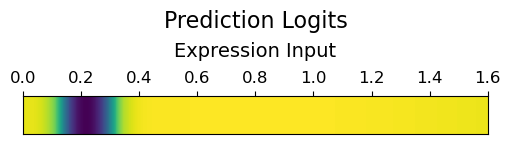

In [111]:

    
plot_single_row_heatmap(prediction_logits, tg_input_values, "Prediction Logits")

The prediction logits are normally logsumexp pooled across cells to get the most confidently predicted score. We will skip this because we are only dealing with the prediction from one cell.

The final step is to pass the cell logit through the sigmoid function to map it to a probability between [0-1].

Prediction Probabilities Shape: torch.Size([1000, 1])


/tmp/ipykernel_99398/1217174604.py:417: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["1"], fontsize=12)


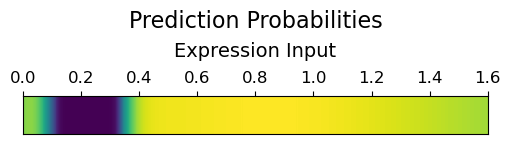

In [113]:
prediction_probs = torch.sigmoid(prediction_logits)
print(f"Prediction Probabilities Shape: {prediction_probs.shape}")


plot_single_row_heatmap(prediction_probs, tg_input_values, "Prediction Probabilities")

We can plot the probabilities as a line graph to see how the model predictions change for the first edge as we change the TG expression.

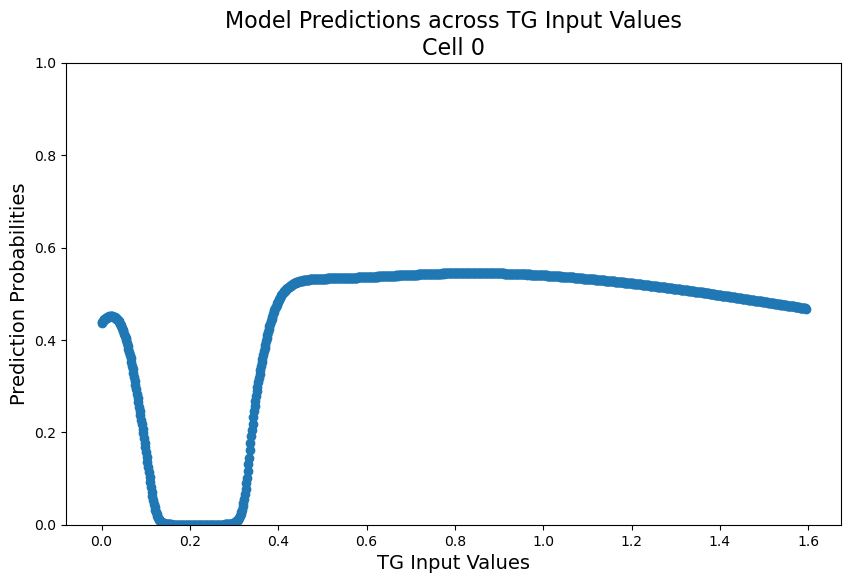

In [114]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    tg_input_values,
    prediction_probs.detach().cpu().numpy(), 
    marker='o',
    linestyle='-'
    )

ax.set_xlabel('TG Input Values', fontsize=14)
ax.set_ylabel('Prediction Probabilities', fontsize=14)
ax.set_title(f'Model Predictions across TG Input Values\nCell {valid_cell_idx}', fontsize=16)
ax.set_ylim(0, 1)

plt.show()

### Testing model response to changes in TF and TG

Now that we see how one cell responds to a change in TG expression, we can also see how the predictions change for a range of cells or edges.

In [48]:
edge_num = 0
cell_num = 0

In [115]:
# Get the first batch and select one cell
B, C = first_batch["cell_mask"].shape
valid_cell_idx = first_batch["cell_mask"][edge_num].bool().nonzero()[cell_num, 0].item() # Cell index

sample_id = first_batch['sample_id'][edge_num]
cell_type = first_batch['cell_type'][edge_num]
tf = first_batch['tf_name'][edge_num]
tg = first_batch['tg_id'][edge_num]

print(f"Sample: {sample_id}")
print(f"Cell Type: {cell_type}")
print(f"TF: {tf}")
print(f"TG: {tg}")
print(f"Selected cell index: {valid_cell_idx}")

# GENE EXPRESSION INFO
tf_token_tensor, tf_input_values_small = project_expression(model.tf_expr_proj, tf_expression_mean, tf_expression_std, device, num=100)
tg_token_tensor, tg_input_values_small = project_expression(model.tg_expr_proj, tg_expression_mean, tg_expression_std, device, num=100)

tf_token_tensor = torch.tensor(tf_token_tensor, device=device)
tg_token_tensor = torch.tensor(tg_token_tensor, device=device)

print(tg_token_tensor.shape)
print(tf_token_tensor.shape)

n_tf = len(tf_input_values_small)
n_tg = len(tg_input_values_small)

assert tf_token_tensor.shape == (n_tf, d_model)
assert tg_token_tensor.shape == (n_tg, d_model)

tf_idx, tg_idx = torch.meshgrid(
    torch.arange(n_tf, device=device),
    torch.arange(n_tg, device=device),
    indexing="ij",
)

tf_idx = tf_idx.reshape(-1)
tg_idx = tg_idx.reshape(-1)

# Select the corresponding TF and TG token for all 10,000 pairs.
tf_grid_tokens = tf_token_tensor[tf_idx]
tg_grid_tokens = tg_token_tensor[tg_idx]

queries = model.tg_query_proj(
    tf_grid_tokens + tg_grid_tokens
)

# PEAK INFO
reference_features = first_batch_peak_features.reshape(B, C, -1, 4)[edge_num, valid_cell_idx]

# Apply the peak mask to only get the applicable peaks for the chosen cell
reference_mask = first_batch["peak_mask"][edge_num].bool().to(device)
reference_features = reference_features[reference_mask]
print(f"Reference features shape after masking: {reference_features.shape}")

# Project the reference features into the model's embedding space
reference_tokens = model.peak_feature_proj(reference_features)
print(f"Reference tokens shape: {reference_tokens.shape}")

# MODEL PREDICTIONS
attention_output_chunks = []
attention_weight_chunks = []

batch_size = 64

with torch.inference_mode():
    for start in range(0, queries.shape[0], batch_size):
        batch_queries = (
            queries[start:start + batch_size]
            .unsqueeze(1)
            .contiguous()
        )

        n = batch_queries.shape[0]

        # Materialized contiguous copies.
        keys = (
            reference_tokens
            .unsqueeze(0)
            .repeat(n, 1, 1)
            .contiguous()
        )

        attn_out, weights = model.peak_attention(
            query=batch_queries,
            key=keys,
            value=keys,
            need_weights=True,
            average_attn_weights=False,
        )

        # Move completed chunks to CPU to avoid retaining GPU memory.
        attention_output_chunks.append(
            attn_out[:, 0, :].cpu()
        )

        attention_weight_chunks.append(
            weights[:, :, 0, :].cpu()
        )

attention_output = torch.cat(
    attention_output_chunks,
    dim=0,
).to(device)

attention_by_head = torch.cat(
    attention_weight_chunks,
    dim=0,
)

print("Attention output:", attention_output.shape)
print("Attention weights:", attention_by_head.shape)

attention_output_norm = model.norm(attention_output)

features = torch.cat(
    [
        attention_output_norm,
        tf_grid_tokens,
        tg_grid_tokens,
    ],
    dim=-1,
)

print(features.shape)
# [10000, 3 * d_model]

with torch.inference_mode():
    prediction_logits = model.classifier(features)
    
    prediction_probs = torch.sigmoid(
        prediction_logits
    ).squeeze(-1)
    
tf_values_tensor = torch.as_tensor(
    tf_input_values_small,
    device=device,
)

tg_values_tensor = torch.as_tensor(
    tg_input_values_small,
    device=device,
)

output_tf_values = tf_values_tensor[tf_idx] # [10000]
output_tg_values = tg_values_tensor[tg_idx] # [10000]

n_tf = len(tf_input_values_small)
n_tg = len(tg_input_values_small)

prediction_grid = (
    prediction_probs
    .detach()
    .cpu()
    .numpy()
    .squeeze()
    .reshape(n_tf, n_tg)
)

print(prediction_grid.shape)
# (100, 100)

tf_values = np.asarray(tf_input_values_small)
tg_values = np.asarray(tg_input_values_small)


Sample: E7.5_rep1
Cell Type: Neurectoderm
TF: SOX2
TG: LAMA3
Selected cell index: 0
torch.Size([100, 128])
torch.Size([100, 128])
Reference features shape after masking: torch.Size([25, 4])
Reference tokens shape: torch.Size([25, 128])
Attention output: torch.Size([10000, 128])
Attention weights: torch.Size([10000, 4, 25])
torch.Size([10000, 384])
(100, 100)


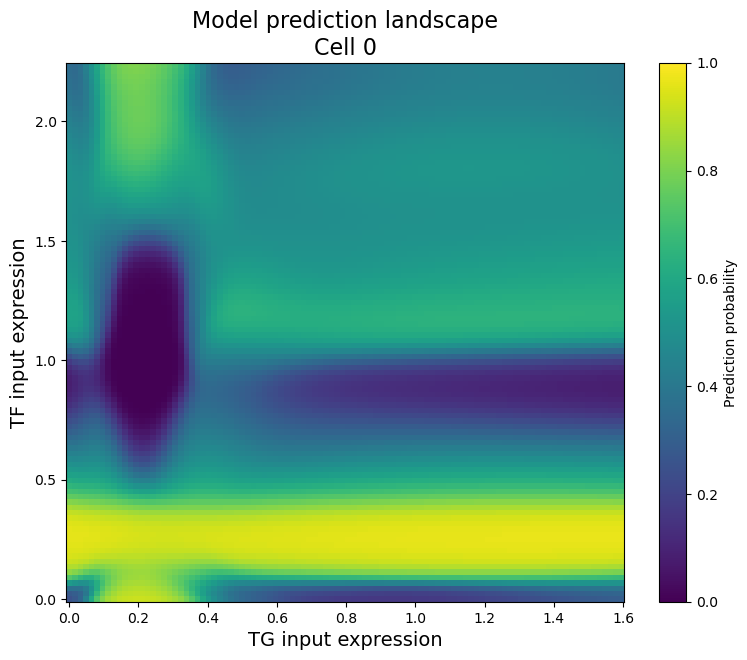

In [116]:

fig, ax = plt.subplots(figsize=(9, 7))

mesh = ax.pcolormesh(
    tg_values,
    tf_values,
    prediction_grid,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.set_xlabel("TG input expression", fontsize=14)
ax.set_ylabel("TF input expression", fontsize=14)
ax.set_title(
    f"Model prediction landscape\nCell {valid_cell_idx}",
    fontsize=16,
)

fig.colorbar(
    mesh,
    ax=ax,
    label="Prediction probability",
)

plt.show()

In [117]:
prediction_grid.shape

(100, 100)

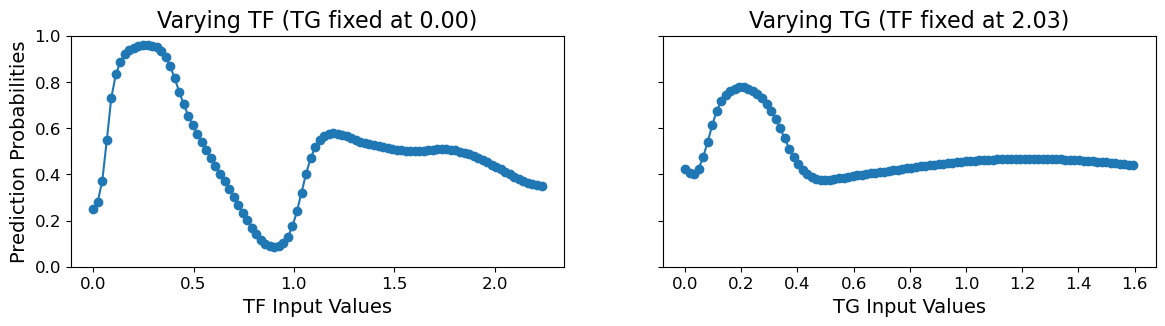

In [143]:
tf_i = 90 # row: which fixed TF value
tg_j = 0   # column: which fixed TG value

fig, (ax_tf, ax_tg) = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

# Vary TF, hold TG fixed
ax_tf.plot(tf_values, prediction_grid[:, tg_j], marker="o", linestyle="-")
ax_tf.set_xlabel("TF Input Values", fontsize=14)
ax_tf.set_ylabel("Prediction Probabilities", fontsize=14)
ax_tf.set_title(f"Varying TF (TG fixed at {tg_values[tg_j]:.2f})", fontsize=16)

# Vary TG, hold TF fixed
ax_tg.plot(tg_values, prediction_grid[tf_i, :], marker="o", linestyle="-")
ax_tg.set_xlabel("TG Input Values", fontsize=14)
ax_tg.set_title(f"Varying TG (TF fixed at {tf_values[tf_i]:.2f})", fontsize=16)

for ax in (ax_tf, ax_tg):
    ax.tick_params(labelsize=12)
    ax.set_ylim(0, 1)

plt.show()


In [51]:
import numpy as np
import plotly.graph_objects as go

tf_values = np.asarray(tf_values)
tg_values = np.asarray(tg_values)
prediction_grid = np.asarray(prediction_grid)

TG, TF = np.meshgrid(
    tg_values,
    tf_values,
    indexing="xy",
)

assert prediction_grid.shape == TG.shape

fig = go.Figure(
    data=go.Surface(
        x=TG,
        y=TF,
        z=prediction_grid,
        surfacecolor=prediction_grid,
        colorscale="Viridis",
        cmin=0,
        cmax=1,
        colorbar=dict(
            title="Prediction<br>probability",
        ),
        hovertemplate=(
            "TG expression: %{x:.3f}<br>"
            "TF expression: %{y:.3f}<br>"
            "Prediction: %{z:.4f}"
            "<extra></extra>"
        ),
        contours=dict(
            z=dict(
                show=True,
                usecolormap=True,
                project_z=True,
                highlightcolor="white",
            )
        ),
    )
)

fig.update_layout(
    title=dict(
        text=f"Model prediction landscape<br><sup>{tf}-{tg}, {sample_id} {cell_type}, Cell {valid_cell_idx}</sup>",
        x=0.5,
    ),
    scene=dict(
        xaxis_title="TG input expression",
        yaxis_title="TF input expression",
        zaxis_title="Prediction probability",
        zaxis=dict(
            range=[0, 1],
        ),
        aspectmode="manual",
        aspectratio=dict(
            x=1.2,
            y=1.0,
            z=0.7,
        ),
        camera=dict(
            eye=dict(
                x=1.5,
                y=-1.5,
                z=1.1,
            )
        ),
    ),
    width=950,
    height=750,
    margin=dict(
        l=20,
        r=20,
        t=80,
        b=20,
    ),
)

fig.show()

We can run these predictions for many cells and edges to see if there are general trends that emerge in how our model changes it's predictions based on the TF and TG expression values.

In [52]:
model_keys = ["binding_score", "peak_accessibility", "peak_distance",
              "tf_expression", "tg_expression", "cell_mask", "peak_mask"]

def model_prediction_grid(lit_model, batch, edge_ids, tf_values, tg_values, points_per_pass=4):
    """Edge probabilities from the full model with every real cell set to (tf, tg).

    Returns [n_edges, n_tf, n_tg].
    """
    lit_model.eval().to(device)
    base = {k: batch[k][edge_ids].to(device) for k in model_keys}
    n_edges = len(edge_ids)

    tf_g, tg_g = np.meshgrid(tf_values, tg_values, indexing="ij")
    tf_flat = torch.as_tensor(tf_g.ravel(), dtype=torch.float32, device=device)
    tg_flat = torch.as_tensor(tg_g.ravel(), dtype=torch.float32, device=device)

    chunks = []
    with torch.inference_mode():
        for s in range(0, len(tf_flat), points_per_pass):
            tf_pts = tf_flat[s:s + points_per_pass]
            tg_pts = tg_flat[s:s + points_per_pass]
            k = len(tf_pts)

            # Rows [i*n_edges, (i+1)*n_edges) are the same edges at grid point i.
            mb = {key: v.repeat(k, *([1] * (v.dim() - 1))) for key, v in base.items()}
            mb["tf_expression"] = tf_pts.repeat_interleave(n_edges)[:, None].expand_as(mb["tf_expression"]).contiguous()
            mb["tg_expression"] = tg_pts.repeat_interleave(n_edges)[:, None].expand_as(mb["tg_expression"]).contiguous()

            edge_logits, _ = lit_model(mb)   # forward() masks padded cells itself
            chunks.append(edge_logits.sigmoid().reshape(k, n_edges).cpu())

    probs = torch.cat(chunks)                # [n_tf * n_tg, n_edges]
    return probs.T.reshape(n_edges, len(tf_values), len(tg_values)).numpy()

# Fixed grid for every batch: 0 to the 99th percentile of real cells in the first batch.
cell_mask = first_batch["cell_mask"].bool()
tf_max = float(np.quantile(first_batch["tf_expression"][cell_mask].numpy(), 0.99))
tg_max = float(np.quantile(first_batch["tg_expression"][cell_mask].numpy(), 0.99))

n_grid = 25
tf_values = np.linspace(0, tf_max, n_grid)
tg_values = np.linspace(0, tg_max, n_grid)

n_batches = 20          # None = whole test set
landscape_parts, label_parts, meta_parts = [], [], []

total = len(test_dataloader) if n_batches is None else min(n_batches, len(test_dataloader))
for i, batch in enumerate(tqdm(test_dataloader, total=total, desc="Prediction grids")):
    if n_batches is not None and i >= n_batches:
        break

    edge_ids = np.arange(len(batch["label"]))
    landscape_parts.append(
        model_prediction_grid(trained_model, batch, edge_ids, tf_values, tg_values)
    )
    label_parts.append(batch["label"].numpy())
    meta_parts.append(pd.DataFrame({
        "sample": batch["sample_id"], "cell_type": batch["cell_type"],
        "tf": batch["tf_name"], "tg": batch["tg_id"],
    }))

all_edge_landscapes = np.concatenate(landscape_parts, axis=0)   # [edges, n_tf, n_tg]
all_edge_labels = np.concatenate(label_parts)
edge_meta = pd.concat(meta_parts, ignore_index=True).assign(label=all_edge_labels)

mean_prediction_grid = all_edge_landscapes.mean(axis=0)
pos_prediction_grid = all_edge_landscapes[all_edge_labels == 1].mean(axis=0)
neg_prediction_grid = all_edge_landscapes[all_edge_labels == 0].mean(axis=0)

print("Edge landscapes:", all_edge_landscapes.shape,
      "| positives:", int(all_edge_labels.sum()))



Prediction grids:   0%|                                | 0/20 [00:00<?, ?it/s]

Prediction grids: 100%|███████████████████████| 20/20 [01:28<00:00,  4.41s/it]

Edge landscapes: (10240, 25, 25) | positives: 3469


In [53]:
model_keys = ["binding_score", "peak_accessibility", "peak_distance",
              "tf_expression", "tg_expression", "cell_mask", "peak_mask"]
peak_feature_names = {"binding_score", "peak_accessibility", "peak_distance"}

CELL_LEVEL = {"tf_expression", "tg_expression"}           # [B, C]
PEAK_LEVEL = {"binding_score", "peak_distance"}           # [B, P]
                                                          # peak_accessibility: [B, C, P]

def valid_feature_values(batch, name):
    """Real (unpadded) raw values of one model input, as a flat array."""
    x = batch[name].float()
    cell = batch["cell_mask"].bool()
    peak = batch["peak_mask"].bool()
    if name in ("tf_expression", "tg_expression"):
        values = x[cell]
    elif name == "peak_accessibility":
        values = x[cell[:, :, None] & peak[:, None, :]]
    else:                                   # binding_score, peak_distance: [B, P]
        values = x[peak]
    if name == "peak_distance":
        values = values.abs()               # forward() uses |distance|
    return values.numpy()


def grid_range(batch, name, n_grid, q=0.99):
    """0 to the q-quantile of the nonzero real values (most inputs are zero-inflated)."""
    values = valid_feature_values(batch, name)
    nonzero = values[values > 0]
    hi = float(np.quantile(nonzero, q)) if len(nonzero) else float(values.max())
    return np.linspace(0, hi, n_grid)


def set_grid_values(mb, name, pts, n_edges):
    """Write one grid value per repeated block of edges into every cell/peak of `name`."""
    target = mb[name]
    vals = pts.repeat_interleave(n_edges).to(target.dtype)          # [k * n_edges]
    mb[name] = vals.reshape(-1, *([1] * (target.dim() - 1))).expand_as(target).contiguous()


def model_prediction_grid(feature1_name, feature2_name, lit_model, batch, edge_ids,
                          feature1_values, feature2_values, points_per_pass=4):
    """Edge probabilities from the full model with every real cell/peak set to (f1, f2).

    Returns [n_edges, n_feature1, n_feature2].
    """
    lit_model.eval().to(device)
    base = {k: batch[k][edge_ids].to(device) for k in model_keys}
    n_edges = len(edge_ids)

    f1_g, f2_g = np.meshgrid(feature1_values, feature2_values, indexing="ij")
    f1_flat = torch.as_tensor(f1_g.ravel(), dtype=torch.float32, device=device)
    f2_flat = torch.as_tensor(f2_g.ravel(), dtype=torch.float32, device=device)

    chunks = []
    with torch.inference_mode():
        for s in range(0, len(f1_flat), points_per_pass):
            f1_pts = f1_flat[s:s + points_per_pass]
            f2_pts = f2_flat[s:s + points_per_pass]
            k = len(f1_pts)

            # Rows [i*n_edges, (i+1)*n_edges) are the same edges at grid point i.
            mb = {key: v.repeat(k, *([1] * (v.dim() - 1))) for key, v in base.items()}
            set_grid_values(mb, feature1_name, f1_pts, n_edges)
            set_grid_values(mb, feature2_name, f2_pts, n_edges)

            edge_logits, _ = lit_model(mb)   # forward() masks padded cells/peaks itself
            chunks.append(edge_logits.sigmoid().reshape(k, n_edges).cpu())

    probs = torch.cat(chunks)                # [n_f1 * n_f2, n_edges]
    return probs.T.reshape(n_edges, len(feature1_values), len(feature2_values)).numpy()

def paired_feature_values(batch, name1, name2, edge_ids):
    """Real raw values of two inputs at a shared unit, plus each point's edge label."""
    cell = batch["cell_mask"].bool()[edge_ids]
    peak = batch["peak_mask"].bool()[edge_ids]
    labels = batch["label"][edge_ids].float()

    def get(name):
        x = batch[name][edge_ids].float()
        return x.abs() if name == "peak_distance" else x   # forward() uses |distance|

    names = {name1, name2}
    if names <= CELL_LEVEL:                                # one point per real cell
        mask = cell
        pair = [get(n) for n in (name1, name2)]
        lab = labels[:, None].expand_as(mask)
    elif names <= PEAK_LEVEL:                              # one point per real peak
        mask = peak
        pair = [get(n) for n in (name1, name2)]
        lab = labels[:, None].expand_as(mask)
    else:                                                  # one point per real (cell, peak)
        mask = cell[:, :, None] & peak[:, None, :]
        def to_bcp(name):
            x = get(name)
            if name in CELL_LEVEL:
                return x[:, :, None]
            if name in PEAK_LEVEL:
                return x[:, None, :]
            return x
        pair = [to_bcp(n).expand_as(mask) for n in (name1, name2)]
        lab = labels[:, None, None].expand_as(mask)

    return pair[0][mask].numpy(), pair[1][mask].numpy(), lab[mask].numpy()

feature1_name = "binding_score"
feature2_name = "peak_accessibility"
n_grid = 25
n_batches = 20

feature1_values = grid_range(first_batch, feature1_name, n_grid)
feature2_values = grid_range(first_batch, feature2_name, n_grid)
varies_peaks = bool({feature1_name, feature2_name} & peak_feature_names)

landscape_parts, label_parts, meta_parts, real_parts = [], [], [], []
total = len(test_dataloader) if n_batches is None else min(n_batches, len(test_dataloader))
for i, batch in enumerate(tqdm(test_dataloader, total=total, desc="Prediction grids")):
    if n_batches is not None and i >= n_batches:
        break

    # Edges without peaks ignore peak features (zero context), so leave them out.
    if varies_peaks:
        edge_ids = np.flatnonzero(batch["peak_mask"].bool().any(1).numpy())
    else:
        edge_ids = np.arange(len(batch["label"]))

    landscape_parts.append(model_prediction_grid(
        feature1_name, feature2_name, trained_model, batch, edge_ids,
        feature1_values, feature2_values,
    ))
    label_parts.append(batch["label"][edge_ids].numpy())
    meta_parts.append(pd.DataFrame({
        "sample": np.asarray(batch["sample_id"])[edge_ids],
        "cell_type": np.asarray(batch["cell_type"])[edge_ids],
        "tf": np.asarray(batch["tf_name"])[edge_ids],
        "tg": np.asarray(batch["tg_id"])[edge_ids],
    }))
    real_parts.append(paired_feature_values(batch, feature1_name, feature2_name, edge_ids))

real_f1 = np.concatenate([p[0] for p in real_parts])
real_f2 = np.concatenate([p[1] for p in real_parts])
real_labels = np.concatenate([p[2] for p in real_parts])

all_edge_landscapes = np.concatenate(landscape_parts, axis=0)   # [edges, n_f1, n_f2]
all_edge_labels = np.concatenate(label_parts)
edge_meta = pd.concat(meta_parts, ignore_index=True).assign(label=all_edge_labels)

mean_prediction_grid = all_edge_landscapes.mean(axis=0)
pos_prediction_grid = all_edge_landscapes[all_edge_labels == 1].mean(axis=0)
neg_prediction_grid = all_edge_landscapes[all_edge_labels == 0].mean(axis=0)

print("Edge landscapes:", all_edge_landscapes.shape,
      "| positives:", int(all_edge_labels.sum()))


Prediction grids: 100%|███████████████████████| 20/20 [01:27<00:00,  4.37s/it]

Edge landscapes: (10240, 25, 25) | positives: 3469


In [54]:
import plotly.graph_objects as go
from scipy.stats import binned_statistic_2d

color_by = "prediction"     # "prediction" | "predicted_true" | "observed_true"
true_threshold = 0.5
min_points = 5               # hide observed bins with fewer real points


def grid_bin_edges(values):
    """Bin edges halfway between grid points, so bin i is centred on grid value i."""
    mids = (values[1:] + values[:-1]) / 2
    return np.concatenate([
        [values[0] - (values[1] - values[0]) / 2],
        mids,
        [values[-1] + (values[-1] - values[-2]) / 2],
    ])


def surface_color(color_by):
    if color_by == "prediction":
        return dict(surfacecolor=mean_prediction_grid, cmin=0, cmax=1,
                    colorscale="Viridis", title="Mean<br>probability")

    if color_by == "predicted_true":
        frac = (all_edge_landscapes >= true_threshold).mean(axis=0)
        return dict(surfacecolor=frac, cmin=0, cmax=1, colorscale="Viridis",
                    title=f"Fraction of edges<br>with p ≥ {true_threshold}")

    if color_by == "observed_true":
        bins = [grid_bin_edges(feature1_values), grid_bin_edges(feature2_values)]
        frac = binned_statistic_2d(real_f1, real_f2, real_labels, "mean", bins=bins).statistic
        count = binned_statistic_2d(real_f1, real_f2, real_labels, "count", bins=bins).statistic
        frac[count < min_points] = np.nan
        base_rate = real_labels.mean()        # white = same True rate as the data overall
        return dict(surfacecolor=frac, cmin=0, cmax=1, cmid=base_rate,
                    colorscale="RdBu_r",
                    title=f"Observed fraction True<br>(base rate {base_rate:.2f})")

    raise ValueError(f"Unknown color_by: {color_by}")


feature2_x, feature1_y = np.meshgrid(feature2_values, feature1_values, indexing="xy")
color = surface_color(color_by)

fig = go.Figure(go.Surface(
    x=feature2_x,
    y=feature1_y,
    z=mean_prediction_grid,
    surfacecolor=color["surfacecolor"],
    customdata=color["surfacecolor"],
    colorscale=color["colorscale"],
    cmin=color["cmin"],
    cmax=color["cmax"],
    cmid=color.get("cmid"),
    colorbar=dict(title=color["title"]),
    hovertemplate=(
        f"{feature2_name}: %{{x:.3f}}<br>"
        f"{feature1_name}: %{{y:.3f}}<br>"
        "Mean prediction: %{z:.4f}<br>"
        "Color value: %{customdata:.3f}"
        "<extra></extra>"
    ),
))

fig.update_layout(
    title=(
        f"Prediction Landscape for {feature1_name} vs {feature2_name}"
        f"<br><sup>{len(all_edge_labels)} edges | color: {color_by}</sup>"
    ),
    scene=dict(
        xaxis_title=feature2_name,
        yaxis_title=feature1_name,
        zaxis_title="Mean prediction probability",
        zaxis=dict(range=[0, 1]),
        aspectratio=dict(x=1.2, y=1.0, z=0.7),
    ),
    width=950,
    height=750,
)
fig.show()

out_dir = PROJECT_DIR / "new_plots" / "prediction_landscapes"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"{feature1_name}_vs_{feature2_name}_{color_by}_landscape.html"
fig.write_html(out_path, include_plotlyjs=True, full_html=True)
print(f"Saved {out_path}")


Saved /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/new_plots/prediction_landscapes/binding_score_vs_peak_accessibility_prediction_landscape.html
